In [1]:
import sys
import os
# 获取当前 notebook 所在目录的父目录的父目录（即项目根目录）
project_root = os.path.dirname(os.path.dirname(os.path.abspath('.')))
sys.path.append(project_root)

In [3]:
from util import Score_calculate as score
from transformers import T5Tokenizer, T5ForConditionalGeneration
import pandas as pd
from tqdm import tqdm
import torch

In [4]:
# === 2. 定义生成函数 ===
def generate_smiles_from_caption(caption, tokenizer, model, max_length=128):
    inputs = tokenizer(caption, return_tensors="pt", truncation=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=5,
            early_stopping=True
        )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded.strip()

In [5]:
# 微调模型生成指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/mnt/slowdisk/ZYH/LLMCP/CheckPoint/SingMolT5_large/checkpoint-544", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/mnt/slowdisk/ZYH/LLMCP/CheckPoint/SingMolT5_large/checkpoint-544')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv")  # 包含 Caption 和 SMILES 列
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
ft_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    ft_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, ft_generated_smiles)

score.result_output(results)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Generating SMILES: 100%|██████████| 60/60 [00:43<00:00,  1.38it/s]


=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.5804
Levenshtein Similarity: 0.6529
MACCS FTS             : 0.7851
RDK FTS               : 0.5280
Morgan FTS            : 0.4885
Validity              : 0.9833


In [6]:
# molt5指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/mnt/slowdisk/ZYH/LLMCP/molt5large_cp2sm", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/mnt/slowdisk/ZYH/LLMCP/molt5large_cp2sm')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv")  # 包含 Caption 和 SMILES 列
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
mt5_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    mt5_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, mt5_generated_smiles)

score.result_output(results)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/usr/local/anaconda3/envs/zyhEnv/lib/python3.8/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Generat


=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.4924
Levenshtein Similarity: 0.5717
MACCS FTS             : 0.5768
RDK FTS               : 0.3136
Morgan FTS            : 0.2512
Validity              : 0.9833


In [7]:
# t5指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/mnt/slowdisk/ZYH/LLMCP/t5large_cp2sm", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/mnt/slowdisk/ZYH/LLMCP/t5large_cp2sm')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv")  # 包含 Caption 和 SMILES 列
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
t5_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    t5_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, t5_generated_smiles)

score.result_output(results)

Generating SMILES: 100%|██████████| 60/60 [00:45<00:00,  1.32it/s]


=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.4641
Levenshtein Similarity: 0.5713
MACCS FTS             : 0.5632
RDK FTS               : 0.3051
Morgan FTS            : 0.2106
Validity              : 0.9833


In [8]:
print(f"Model is on device: {model.device}")

Model is on device: cuda:0


In [9]:
print(ft_generated_smiles)

['C1=CC=NC(=C1)CC#CC2=CC=CC=N2', 'CC(=O)C1=CC=NC=C1', 'C1=CC=NC(=C1)CC#CC2=CC=CC=N2', 'C1=CC(=CC=C1C#CC2=CC=C(C=C2)C(=O)O)C(=O)O', 'C1=CC(=CC=C1C#CC2=CC=C(C=C2)C(=O)O)C(=O)O', 'CC#CC1=CC(=C(C=C1)C#CC2=CC=C(C=C2)C(=O)O)C(=O)O', 'C1=CC2=C(C=C1)C3=C(C2=O)C=CC(=C3)S', 'C1=CC2=C3C(=C1)C=CC4=CC(=CC(=C43)S2)S', 'C1=CC2=C3C(=C1)C=CC4=CC(=CC(=C43)C=C2)S', 'C1=CC(=CC=C1C2=CC=C(C=C2)N)N', 'C1=CC(=CC=C1C2=CC=C(C=C2)N)N', 'C1=CC(=CC=C1C2=CC=C(C=C2)N)N', 'CSC1=CC=C2C=C(SC)C=CC2=C1', 'CSC1=CC2=C(C=CC(=C2)SC)C=C1', 'CSC1=CC=C2C=C(SC)C=CC2=C1', 'C1=CC(=NC(=C1)C#N)S', 'C1=CN=CC=C1S', 'C1=CN=CC=C1S', 'CC(=O)SC1=CC=NC(=C1)CSC(=O)C', 'CC(=O)SC1=CC=NC(=C1)CSC', 'CC(=O)SC1=CC=NC=C1', 'CNC1=CC=C(C#N)C#N', 'CNC1=CC=C(C=C1)C#N', 'CNC1=CC=C(C#N)C=C1', 'C1=CC(=CC=C1C#N)C#N', 'C1=CC(=CC=C1C#N)C#N', 'C1=CC(=CC=C1C#N)C#N', 'C1=CC2=C(C=CC=C2I)C=C1', 'C1=CC2=C(C=CC=C2I)C=C1I', 'C1=CC2=C(C=CC=C2I)C=C1I', 'C1=CC2=C(C=C1SC)C3=C(C=C2)C=C(S3)C4=CC=CS4', 'C1=CSC(=C1)C2=CC=C(S2)C3=CC=C(S3)C4=CC=CS4', 'C1=CC2=C(C=C1SC)C3=C(C=

In [10]:
print(mt5_generated_smiles)

['C1=CC=NC(=C1)CC#N', 'CC(=O)N1CCCC1', 'C1=CC=NC(=C1)CC2=CC=CC=N2', 'C1=CC=C(C(=C1)C2=CC=CC=C2C(=O)O)C(=O)O', 'C1=CC=C(C(=C1)C2=CC=CC=C2C(=O)O)C(=O)O', 'CCC1=CC=CC(=C1N(CC(=O)OCC)CC(=O)OCC)C2=CC=CC=C2', 'C1=CC=C2C(=C1)C=C3C=CC(=CC3=C2)S(=O)(=O)[O-]', 'C1=CC=C2C(=C1)C=C3C=CC=CC3=N2', 'C1=CC=C2C(=C1)C=C3C=CC4=CC=CC=C4C3=CC=C2S(=O)(=O)O', 'C1=CC=C(C=C1)C2=CC=CC=C2N', 'C1=CC=C(C=C1)C2=CC=CC=C2N', 'C1=CC=C(C=C1)C2=CC=CC=C2N', 'CC1=C(C2=CC=CC=C2C(=C1)SC)C', 'CN=C1C=CC2=CC=CC=C21', 'CC1=C(C2=CC=CC=C2C(=C1)C)SC', 'C1=C(C=[N+](C=C1S(=O)(=O)N)[S-])[S-]', 'C1=CC=NC(=C1)S(=O)(=O)N', 'C1=CNC(=S)N=C1', 'C[C@@H]1[C@H](C=C[C@@H](O1)N2C=CC(=NC2=O)C)SC', 'C[S+](C)C1=CN=CC=C1', 'C[S+](C)C1=CC=CC=C1', 'CNC1=CC=CC=C1', 'CN(C)C1=CC=C(C=C1)C2=CC=CC=N2', 'CNC1=CC=CC=C1', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C2C(=C1)C=CC3=C2C4=CC=CC=C4C=C3', 'C1=CC=C2C(=C1)C=CC3=C2C4=CC=CC=C4C=C3', 'C1=CC=C2C(=C1)C=CC3=C2C4=CC=CC=C4C=C3', 'C1=CC=C2C(=C1)C3=CC=CC=C3S2', 'C1=CC=C2C(=C1)C3=CC=CC=C3S2

In [11]:
print(t5_generated_smiles)

['C1=CC(=CN=C1)C2=CC=NC=C2', 'CC(=O)N1CCCC1', 'CC(=O)C1=CC=CN1', 'C1=CC=C(C=C1)C(C2=CC=CC=C2)(C3=CC=CC=C3)C(=O)O', 'C1=CC=C(C=C1)C(C2=CC=CC=C2)C(=O)[O-]', 'CCC1=CC=CC=C1CC2=CC=CC=C2', 'C1=CC=C2C(=C1)C=CC3=CC=CC=C3S2', 'CC1=CC2=C(C=C1S(=O)(=O)[O-])C(=C3C=C(C(=[NH+]CC)C=C3O2)C)C4=C(C=C(C=C4)S(=O)(=O)[O-])S(=O)(=O)[O-]', 'CC1=C(C2=CC3=C(C(=C(C=C3)S(=O)(=O)O)S(=O)(=O)O)C(=C2C1=O)O)C', 'C1=CC=C(C=C1)C2=CC=CC=C2N', 'C1=CC=C(C=C1)C2=CC=CC=C2N', 'C1=CC=C(C=C1)C2=CC=CC=C2N', 'CSC1=CC=CC2=CC=CC=C21', 'CSC1=CC=CC2=CC=CC=C21', 'CSC1=CC=CC2=CC=CC=C21', 'C1=CC(=NC(=C1)S(=O)(=O)O)S(=O)(=O)O', 'C1=CC=NC(=C1)S(=O)(=O)[O-]', 'C1=CC=NC(=C1)SCC2=CC=CC=N2', 'CSCC[C@H]1C(=O)NC(=C)C1', 'CC(=O)SCC1=CN=C(N=C1)C2=CC=CC=N2', 'CSCC[C@@H]1[C@H](C(=O)N=C(S1)N)NC(=O)[C@@H](C(=O)O)N', 'C[N+]1=CC=CC=C1/C=C/C2=CC=CC=C2', 'CN(C)C1=CC=C(C=C1)C2=CC=CC=C2', 'C[N+]1=CC=CC=C1/C=C/C2=CC=CC=C2', 'C1=CC=C(C=C1)C(=O)C2=CC=C(C=C2)N=C=O', 'C1=CC=C2C(=C1)C=CC(=C2N=C=O)C#N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C2C(=C1)C=C(C(=C2I)N=I)I', 'C1=

Aromatic: C1=CC=NC(=C1)CC#CC2=CC=CC=N2
Kekule:   C(#CC1=CC=CC=N1)CC1=CC=CC=N1

Structure of C(#CC1=CC=CC=N1)CC1=CC=CC=N1


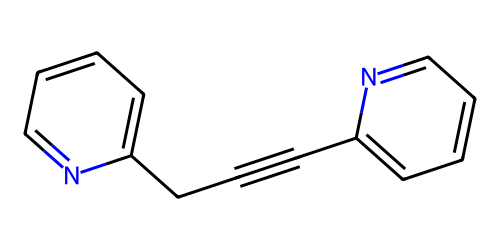

Aromatic: CC(=O)C1=CC=NC=C1
Kekule:   CC(=O)C1=CC=NC=C1

Structure of CC(=O)C1=CC=NC=C1


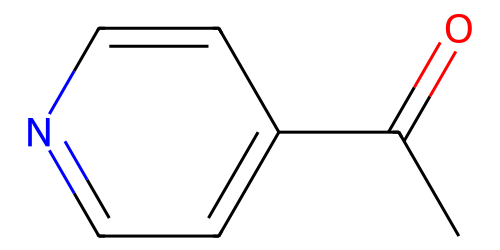

Aromatic: C1=CC=NC(=C1)CC#CC2=CC=CC=N2
Kekule:   C(#CC1=CC=CC=N1)CC1=CC=CC=N1

Structure of C(#CC1=CC=CC=N1)CC1=CC=CC=N1


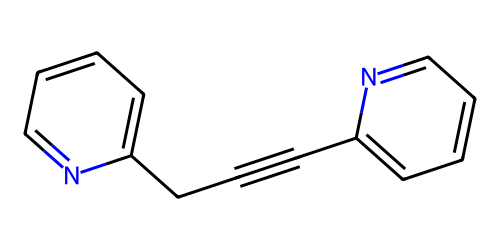

Aromatic: C1=CC(=CC=C1C#CC2=CC=C(C=C2)C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1

Structure of O=C(O)C1=CC=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1


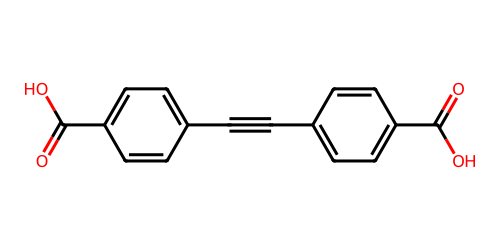

Aromatic: C1=CC(=CC=C1C#CC2=CC=C(C=C2)C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1

Structure of O=C(O)C1=CC=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1


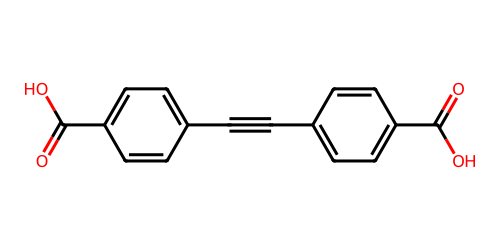

Aromatic: CC#CC1=CC(=C(C=C1)C#CC2=CC=C(C=C2)C(=O)O)C(=O)O
Kekule:   CC#CC1=CC(C(=O)O)=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1

Structure of CC#CC1=CC(C(=O)O)=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1


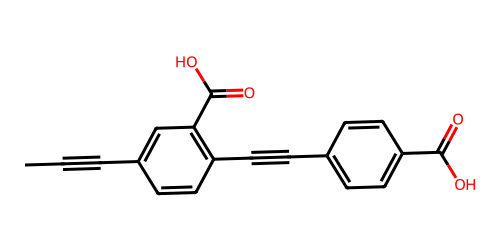

Aromatic: C1=CC2=C(C=C1)C3=C(C2=O)C=CC(=C3)S
Kekule:   O=C1C2=C(C=CC=C2)C2=C1C=CC(S)=C2

Structure of O=C1C2=C(C=CC=C2)C2=C1C=CC(S)=C2


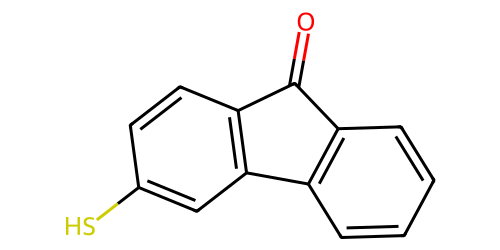

Aromatic: C1=CC2=C3C(=C1)C=CC4=CC(=CC(=C43)S2)S
Kekule:   SC1=CC2=C3C(=C1)C=CC1=CC=CC(=C13)S2

Structure of SC1=CC2=C3C(=C1)C=CC1=CC=CC(=C13)S2


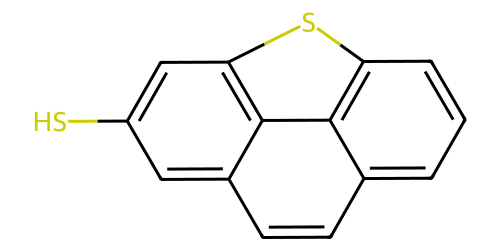

Aromatic: C1=CC2=C3C(=C1)C=CC4=CC(=CC(=C43)C=C2)S
Kekule:   SC1=CC2=C3C(=C1)C=CC1=CC=CC(=C13)C=C2

Structure of SC1=CC2=C3C(=C1)C=CC1=CC=CC(=C13)C=C2


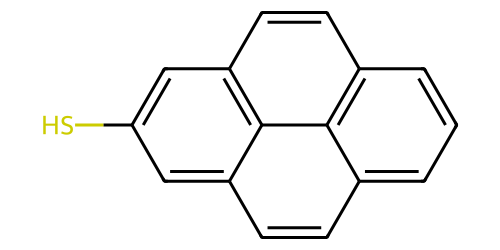

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=C(N)C=C2)C=C1

Structure of NC1=CC=C(C2=CC=C(N)C=C2)C=C1


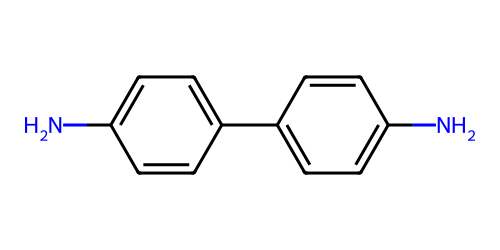

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=C(N)C=C2)C=C1

Structure of NC1=CC=C(C2=CC=C(N)C=C2)C=C1


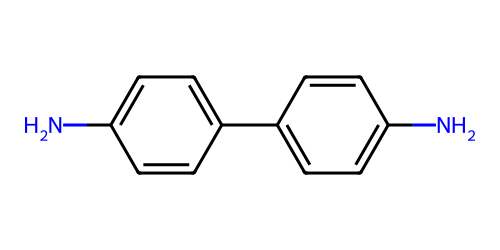

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=C(N)C=C2)C=C1

Structure of NC1=CC=C(C2=CC=C(N)C=C2)C=C1


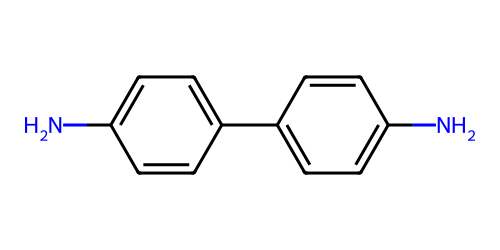

Aromatic: CSC1=CC=C2C=C(SC)C=CC2=C1
Kekule:   CSC1=CC=C2C=C(SC)C=CC2=C1

Structure of CSC1=CC=C2C=C(SC)C=CC2=C1


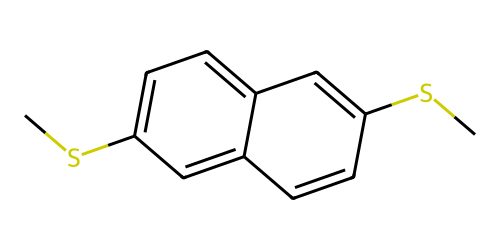

Aromatic: CSC1=CC2=C(C=CC(=C2)SC)C=C1
Kekule:   CSC1=CC2=C(C=C1)C=CC(SC)=C2

Structure of CSC1=CC2=C(C=C1)C=CC(SC)=C2


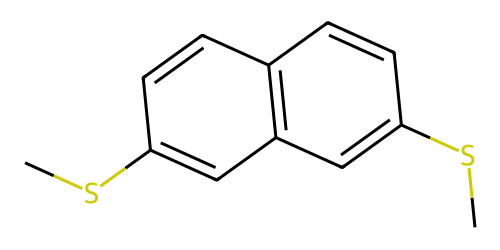

Aromatic: CSC1=CC=C2C=C(SC)C=CC2=C1
Kekule:   CSC1=CC=C2C=C(SC)C=CC2=C1

Structure of CSC1=CC=C2C=C(SC)C=CC2=C1


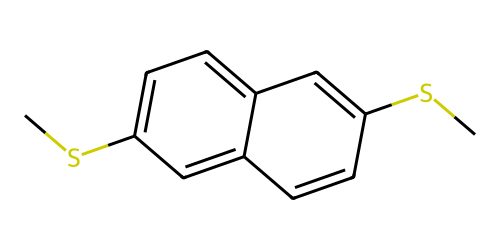

Aromatic: C1=CC(=NC(=C1)C#N)S
Kekule:   N#CC1=CC=CC(S)=N1

Structure of N#CC1=CC=CC(S)=N1


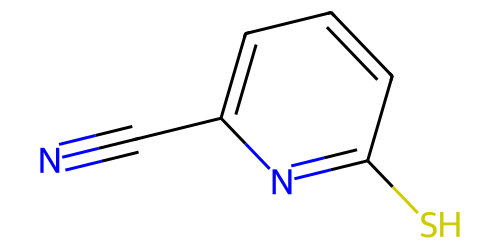

Aromatic: C1=CN=CC=C1S
Kekule:   SC1=CC=NC=C1

Structure of SC1=CC=NC=C1


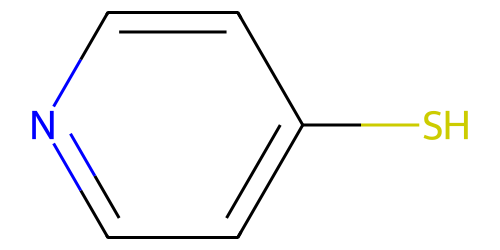

Aromatic: C1=CN=CC=C1S
Kekule:   SC1=CC=NC=C1

Structure of SC1=CC=NC=C1


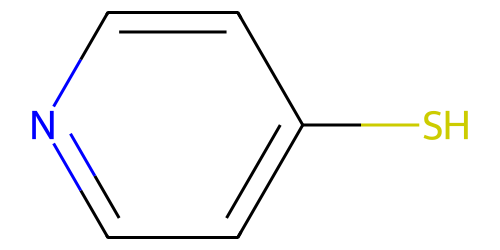

Aromatic: CC(=O)SC1=CC=NC(=C1)CSC(=O)C
Kekule:   CC(=O)SCC1=CC(SC(C)=O)=CC=N1

Structure of CC(=O)SCC1=CC(SC(C)=O)=CC=N1


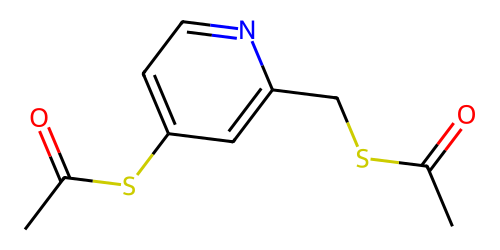

Aromatic: CC(=O)SC1=CC=NC(=C1)CSC
Kekule:   CSCC1=CC(SC(C)=O)=CC=N1

Structure of CSCC1=CC(SC(C)=O)=CC=N1


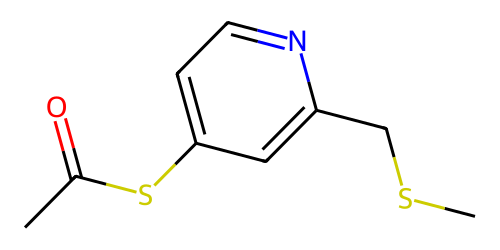

Aromatic: CC(=O)SC1=CC=NC=C1
Kekule:   CC(=O)SC1=CC=NC=C1

Structure of CC(=O)SC1=CC=NC=C1


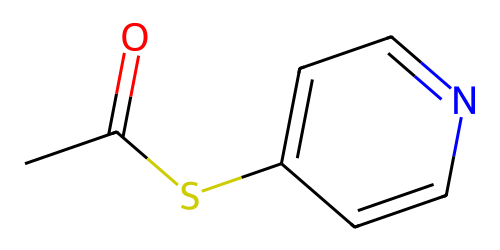

Aromatic: CNC1=CC=C(C#N)C#N
Kekule:   None

Aromatic: CNC1=CC=C(C=C1)C#N
Kekule:   CNC1=CC=C(C#N)C=C1

Structure of CNC1=CC=C(C#N)C=C1


[16:19:35] SMILES Parse Error: unclosed ring for input: 'CNC1=CC=C(C#N)C#N'


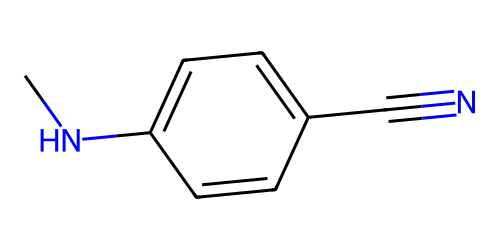

Aromatic: CNC1=CC=C(C#N)C=C1
Kekule:   CNC1=CC=C(C#N)C=C1

Structure of CNC1=CC=C(C#N)C=C1


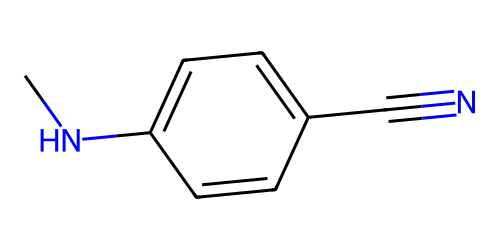

Aromatic: C1=CC(=CC=C1C#N)C#N
Kekule:   N#CC1=CC=C(C#N)C=C1

Structure of N#CC1=CC=C(C#N)C=C1


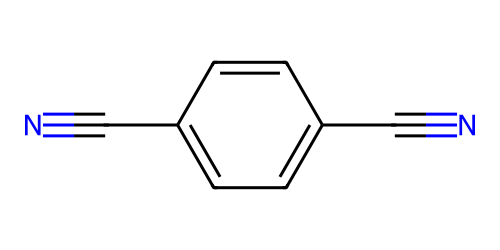

Aromatic: C1=CC(=CC=C1C#N)C#N
Kekule:   N#CC1=CC=C(C#N)C=C1

Structure of N#CC1=CC=C(C#N)C=C1


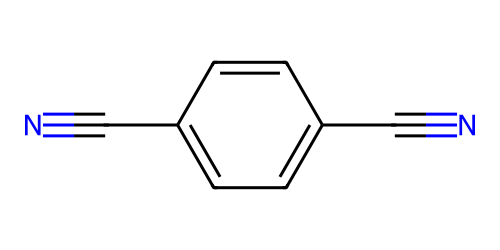

Aromatic: C1=CC(=CC=C1C#N)C#N
Kekule:   N#CC1=CC=C(C#N)C=C1

Structure of N#CC1=CC=C(C#N)C=C1


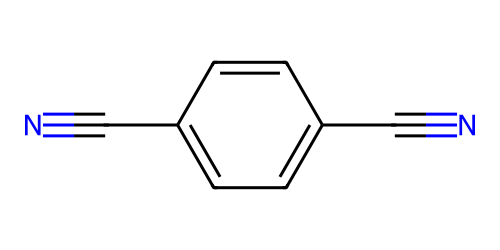

Aromatic: C1=CC2=C(C=CC=C2I)C=C1
Kekule:   IC1=CC=CC2=C1C=CC=C2

Structure of IC1=CC=CC2=C1C=CC=C2


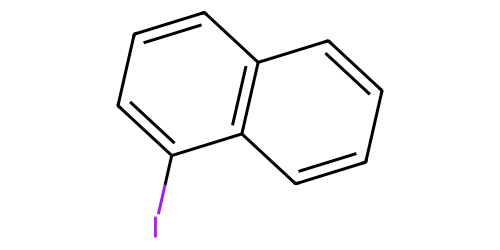

Aromatic: C1=CC2=C(C=CC=C2I)C=C1I
Kekule:   IC1=CC2=C(C=C1)C(I)=CC=C2

Structure of IC1=CC2=C(C=C1)C(I)=CC=C2


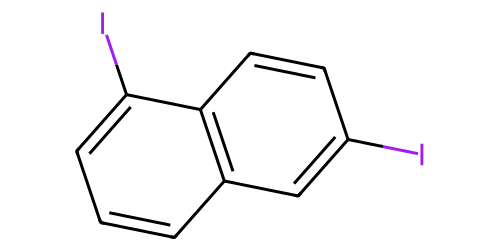

Aromatic: C1=CC2=C(C=CC=C2I)C=C1I
Kekule:   IC1=CC2=C(C=C1)C(I)=CC=C2

Structure of IC1=CC2=C(C=C1)C(I)=CC=C2


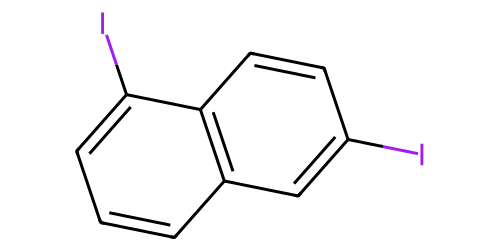

Aromatic: C1=CC2=C(C=C1SC)C3=C(C=C2)C=C(S3)C4=CC=CS4
Kekule:   CSC1=CC2=C(C=C1)C=CC1=C2SC(C2=CC=CS2)=C1

Structure of CSC1=CC2=C(C=C1)C=CC1=C2SC(C2=CC=CS2)=C1


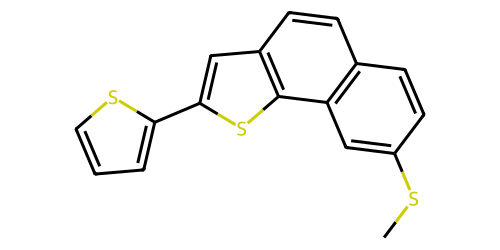

Aromatic: C1=CSC(=C1)C2=CC=C(S2)C3=CC=C(S3)C4=CC=CS4
Kekule:   C1=CSC(C2=CC=C(C3=CC=C(C4=CC=CS4)S3)S2)=C1

Structure of C1=CSC(C2=CC=C(C3=CC=C(C4=CC=CS4)S3)S2)=C1


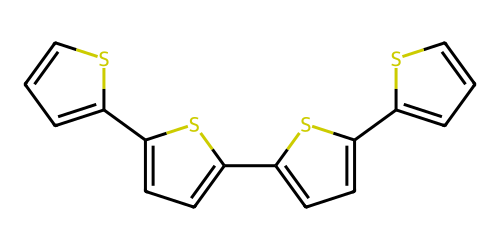

Aromatic: C1=CC2=C(C=C1SC)C3=C(C=C2)C=CS3
Kekule:   CSC1=CC2=C(C=C1)C=CC1=C2SC=C1

Structure of CSC1=CC2=C(C=C1)C=CC1=C2SC=C1


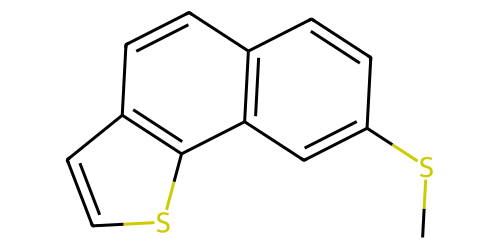

Aromatic: C1=CSC(=C1)C2=CC=C(S2)C#N
Kekule:   N#CC1=CC=C(C2=CC=CS2)S1

Structure of N#CC1=CC=C(C2=CC=CS2)S1


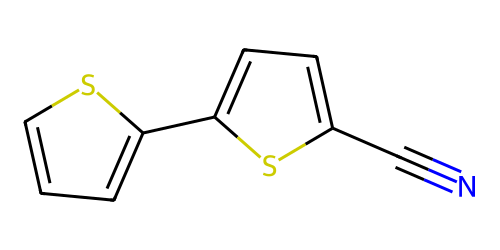

Aromatic: C1=CSC(=C1)C2=CC=C(S2)C#N
Kekule:   N#CC1=CC=C(C2=CC=CS2)S1

Structure of N#CC1=CC=C(C2=CC=CS2)S1


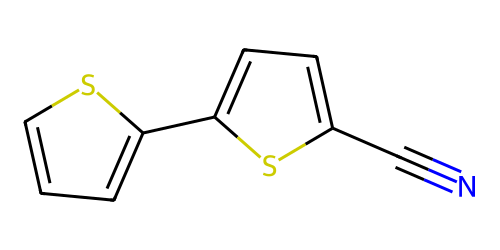

Aromatic: C1=CSC(=C1)C2=CC=C(S2)C#N
Kekule:   N#CC1=CC=C(C2=CC=CS2)S1

Structure of N#CC1=CC=C(C2=CC=CS2)S1


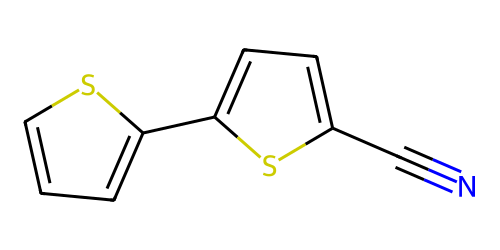

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=C(N)C=C2)C=C1

Structure of NC1=CC=C(C2=CC=C(N)C=C2)C=C1


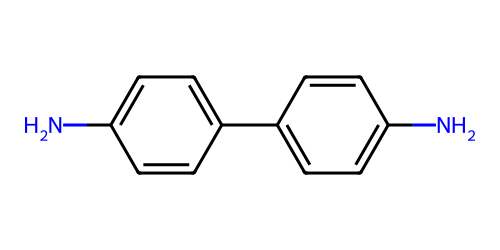

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=C(N)C=C2)C=C1

Structure of NC1=CC=C(C2=CC=C(N)C=C2)C=C1


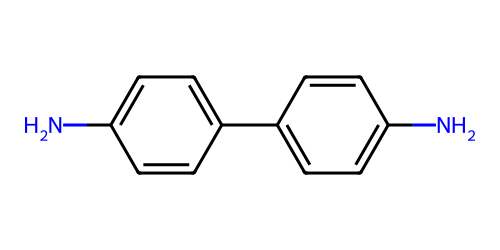

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=C(N)C=C2)C=C1

Structure of NC1=CC=C(C2=CC=C(N)C=C2)C=C1


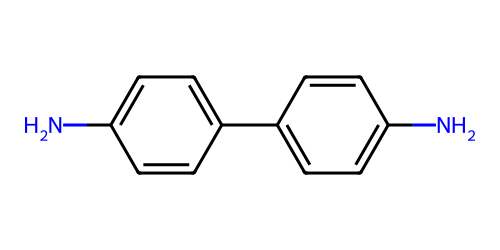

Aromatic: C1=CC2=C(C=CC(=C2)C#CC3=CC=NC=C3)C=C1
Kekule:   C(#CC1=CC2=C(C=CC=C2)C=C1)C1=CC=NC=C1

Structure of C(#CC1=CC2=C(C=CC=C2)C=C1)C1=CC=NC=C1


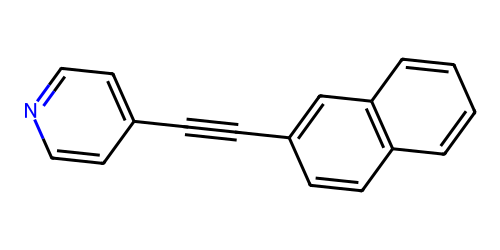

Aromatic: C1=CC=C(C=C1)C2=CC=C(O2)C3=CC=NC=C3
Kekule:   C1=CC=C(C2=CC=C(C3=CC=NC=C3)O2)C=C1

Structure of C1=CC=C(C2=CC=C(C3=CC=NC=C3)O2)C=C1


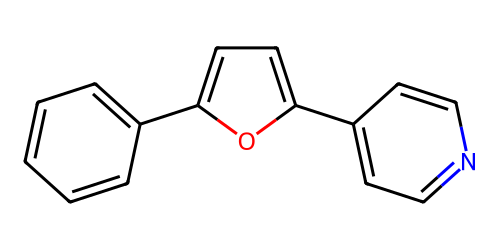

Aromatic: C1=CC2=C(C=C1C3=CC=NC=C3)C=C2
Kekule:   C1=CC(C2=CC3=C(C=C2)C=C3)=CC=N1

Structure of C1=CC(C2=CC3=C(C=C2)C=C3)=CC=N1


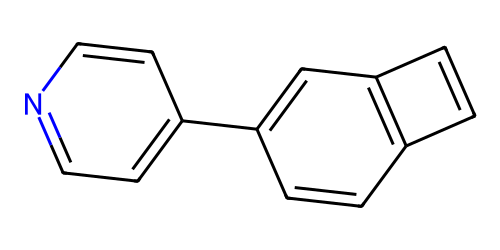

Aromatic: CSC(=O)C1=CC=CC2=CC=CC=C21
Kekule:   CSC(=O)C1=CC=CC2=CC=CC=C21

Structure of CSC(=O)C1=CC=CC2=CC=CC=C21


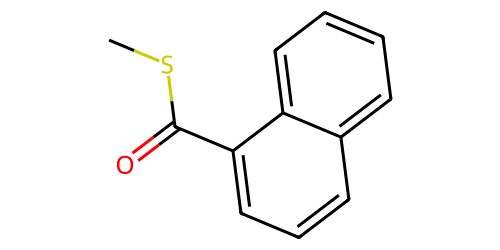

Aromatic: CSC(=O)C1=CC=CC2=CC=CC=C21
Kekule:   CSC(=O)C1=CC=CC2=CC=CC=C21

Structure of CSC(=O)C1=CC=CC2=CC=CC=C21


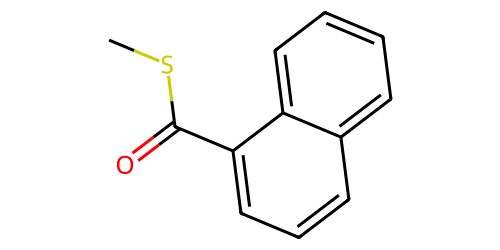

Aromatic: CSC(=O)C1=CC=CC2=CC=CC=C21
Kekule:   CSC(=O)C1=CC=CC2=CC=CC=C21

Structure of CSC(=O)C1=CC=CC2=CC=CC=C21


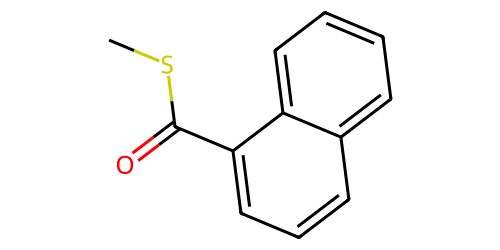

Aromatic: CSC1=CC2=C(C=C1)C3=C(C2=O)C=CC(=C3)SC
Kekule:   CSC1=CC2=C(C=C1)C1=C(C=CC(SC)=C1)C2=O

Structure of CSC1=CC2=C(C=C1)C1=C(C=CC(SC)=C1)C2=O


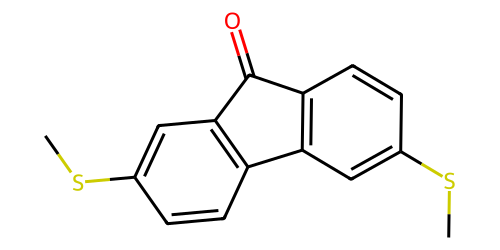

Aromatic: CSC1=CC2=C(C=C1)C3=C(S2)C=C(C=C3)SC
Kekule:   CSC1=CC2=C(C=C1)C1=C(C=C(SC)C=C1)S2

Structure of CSC1=CC2=C(C=C1)C1=C(C=C(SC)C=C1)S2


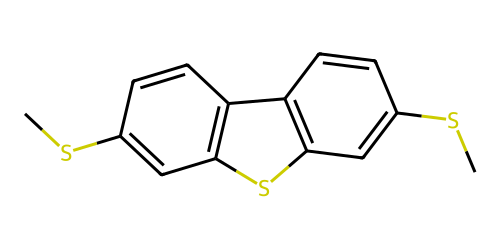

Aromatic: CSC1=CC2=C(C=C1)C3=C(C2=O)C=CC(=C3)SC
Kekule:   CSC1=CC2=C(C=C1)C1=C(C=CC(SC)=C1)C2=O

Structure of CSC1=CC2=C(C=C1)C1=C(C=CC(SC)=C1)C2=O


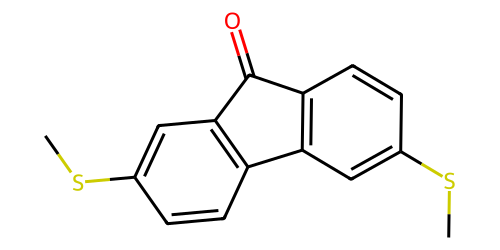

Aromatic: C1=CSC(=C1)C(=O)O
Kekule:   O=C(O)C1=CC=CS1

Structure of O=C(O)C1=CC=CS1


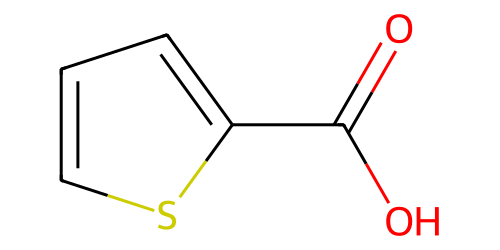

Aromatic: C1=CSC(=C1)C(=O)O
Kekule:   O=C(O)C1=CC=CS1

Structure of O=C(O)C1=CC=CS1


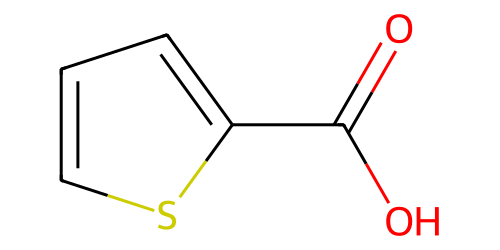

Aromatic: C1=CSC(=C1)C(=O)O
Kekule:   O=C(O)C1=CC=CS1

Structure of O=C(O)C1=CC=CS1


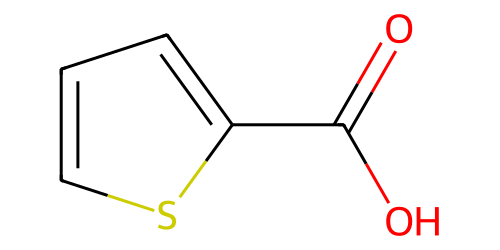

Aromatic: C1=CC2=C(C=C1N)OC3=C2C=CC(=C3)N
Kekule:   NC1=CC2=C(C=C1)C1=C(C=C(N)C=C1)O2

Structure of NC1=CC2=C(C=C1)C1=C(C=C(N)C=C1)O2


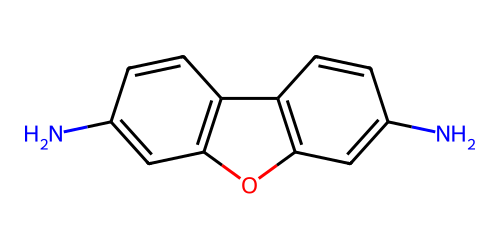

Aromatic: C1=CC2=C(C=C1N)OC3=C2C=CC(=C3)N
Kekule:   NC1=CC2=C(C=C1)C1=C(C=C(N)C=C1)O2

Structure of NC1=CC2=C(C=C1)C1=C(C=C(N)C=C1)O2


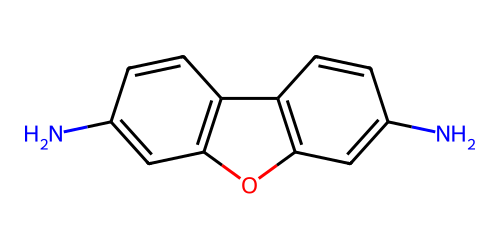

Aromatic: C1=CC2=C(C=C1N)OC3=C2C=CC(=C3)N
Kekule:   NC1=CC2=C(C=C1)C1=C(C=C(N)C=C1)O2

Structure of NC1=CC2=C(C=C1)C1=C(C=C(N)C=C1)O2


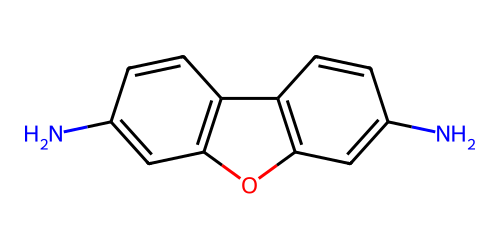

Aromatic: CC1=C(C2=CC=CC=C2C(=C1)N)N
Kekule:   CC1=C(N)C2=CC=CC=C2C(N)=C1

Structure of CC1=C(N)C2=CC=CC=C2C(N)=C1


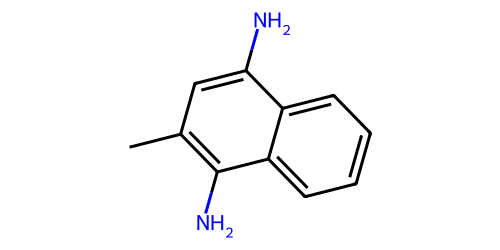

Aromatic: CC1=C(C2=CC=CC=C2C(=C1)N)N
Kekule:   CC1=C(N)C2=CC=CC=C2C(N)=C1

Structure of CC1=C(N)C2=CC=CC=C2C(N)=C1


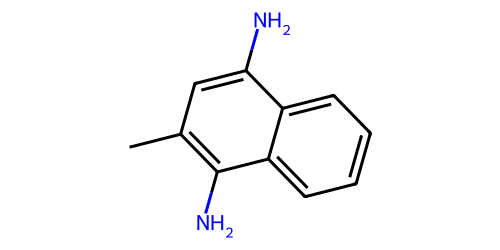

Aromatic: CC1=C(C2=CC=CC=C2C(=C1)N)N
Kekule:   CC1=C(N)C2=CC=CC=C2C(N)=C1

Structure of CC1=C(N)C2=CC=CC=C2C(N)=C1


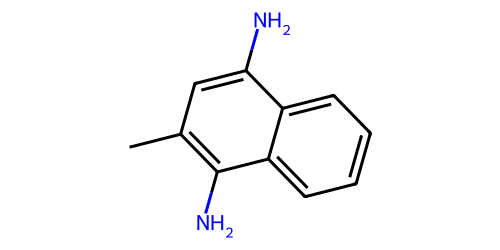

Aromatic: C1=CN=CC=C1
Kekule:   C1=CC=NC=C1

Structure of C1=CC=NC=C1


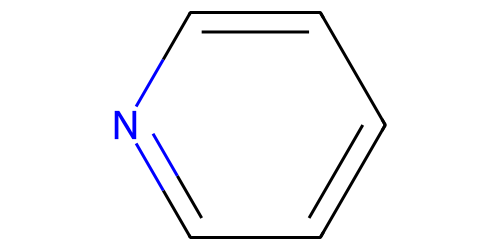

Aromatic: C1=CN=CC=C1
Kekule:   C1=CC=NC=C1

Structure of C1=CC=NC=C1


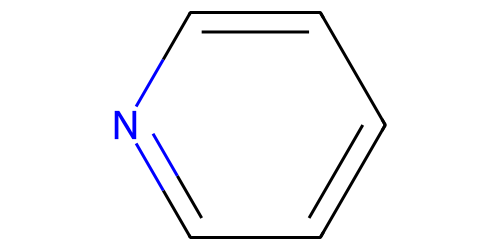

Aromatic: C1=CN=CC=C1
Kekule:   C1=CC=NC=C1

Structure of C1=CC=NC=C1


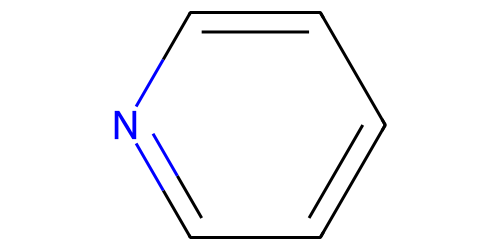

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = ft_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中


Aromatic: C1=CC=NC(=C1)CC#N
Kekule:   N#CCC1=CC=CC=N1

Structure of N#CCC1=CC=CC=N1


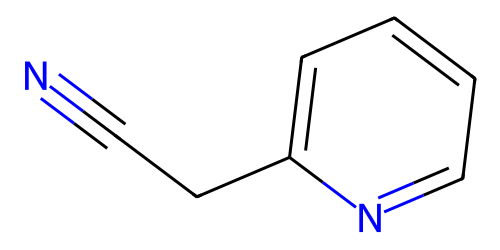

Aromatic: CC(=O)N1CCCC1
Kekule:   CC(=O)N1CCCC1

Structure of CC(=O)N1CCCC1


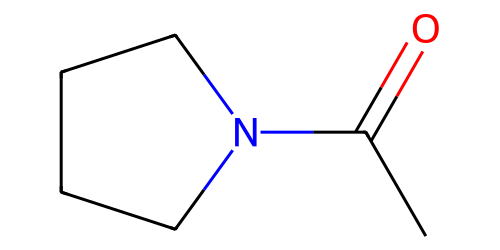

Aromatic: C1=CC=NC(=C1)CC2=CC=CC=N2
Kekule:   C1=CC=C(CC2=CC=CC=N2)N=C1

Structure of C1=CC=C(CC2=CC=CC=N2)N=C1


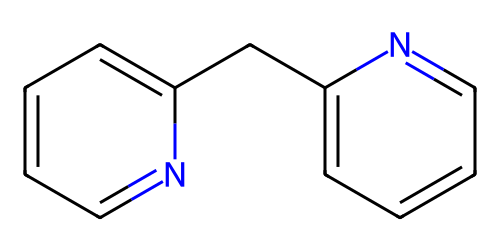

Aromatic: C1=CC=C(C(=C1)C2=CC=CC=C2C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=CC=C1C1=CC=CC=C1C(=O)O

Structure of O=C(O)C1=CC=CC=C1C1=CC=CC=C1C(=O)O


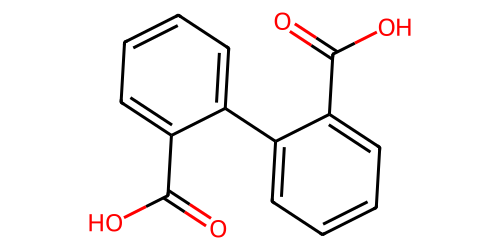

Aromatic: C1=CC=C(C(=C1)C2=CC=CC=C2C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=CC=C1C1=CC=CC=C1C(=O)O

Structure of O=C(O)C1=CC=CC=C1C1=CC=CC=C1C(=O)O


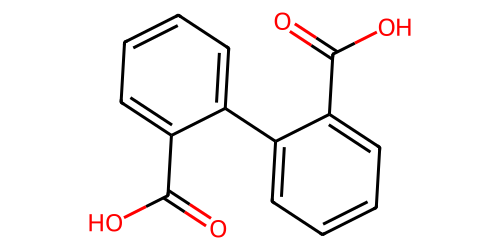

Aromatic: CCC1=CC=CC(=C1N(CC(=O)OCC)CC(=O)OCC)C2=CC=CC=C2
Kekule:   CCOC(=O)CN(CC(=O)OCC)C1=C(C2=CC=CC=C2)C=CC=C1CC

Structure of CCOC(=O)CN(CC(=O)OCC)C1=C(C2=CC=CC=C2)C=CC=C1CC


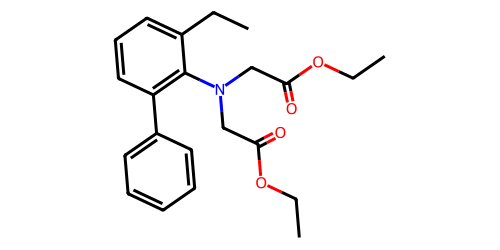

Aromatic: C1=CC=C2C(=C1)C=C3C=CC(=CC3=C2)S(=O)(=O)[O-]
Kekule:   O=S(=O)([O-])C1=CC2=CC3=CC=CC=C3C=C2C=C1

Structure of O=S(=O)([O-])C1=CC2=CC3=CC=CC=C3C=C2C=C1


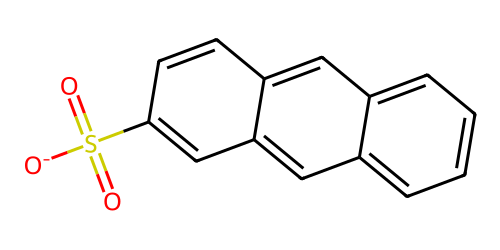

Aromatic: C1=CC=C2C(=C1)C=C3C=CC=CC3=N2
Kekule:   C1=CC=C2N=C3C=CC=CC3=CC2=C1

Structure of C1=CC=C2N=C3C=CC=CC3=CC2=C1


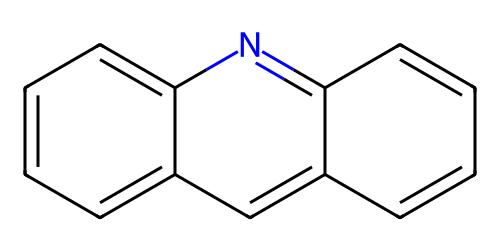

Aromatic: C1=CC=C2C(=C1)C=C3C=CC4=CC=CC=C4C3=CC=C2S(=O)(=O)O
Kekule:   O=S(=O)(O)C1=CC=C2C(=CC3=CC=CC=C31)C=CC1=CC=CC=C12

Structure of O=S(=O)(O)C1=CC=C2C(=CC3=CC=CC=C31)C=CC1=CC=CC=C12


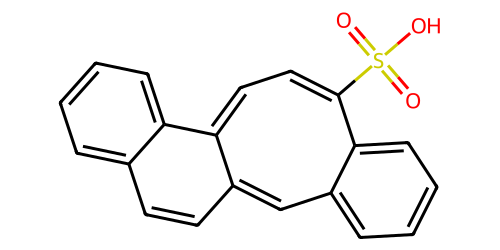

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2N
Kekule:   NC1=CC=CC=C1C1=CC=CC=C1

Structure of NC1=CC=CC=C1C1=CC=CC=C1


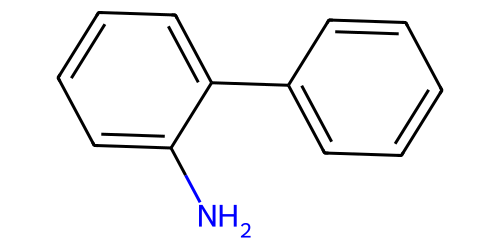

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2N
Kekule:   NC1=CC=CC=C1C1=CC=CC=C1

Structure of NC1=CC=CC=C1C1=CC=CC=C1


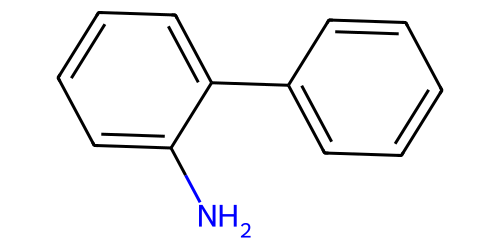

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2N
Kekule:   NC1=CC=CC=C1C1=CC=CC=C1

Structure of NC1=CC=CC=C1C1=CC=CC=C1


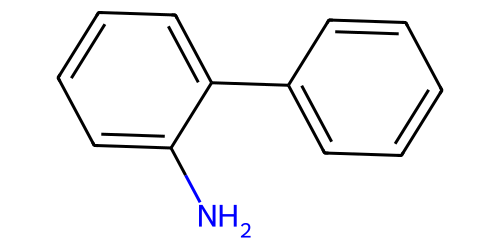

Aromatic: CC1=C(C2=CC=CC=C2C(=C1)SC)C
Kekule:   CSC1=CC(C)=C(C)C2=CC=CC=C12

Structure of CSC1=CC(C)=C(C)C2=CC=CC=C12


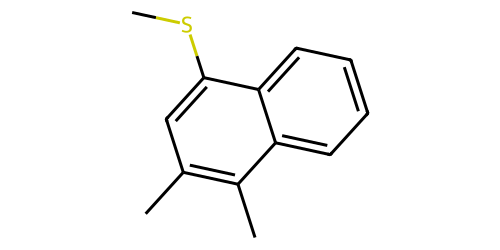

Aromatic: CN=C1C=CC2=CC=CC=C21
Kekule:   CN=C1C=CC2=CC=CC=C21

Structure of CN=C1C=CC2=CC=CC=C21


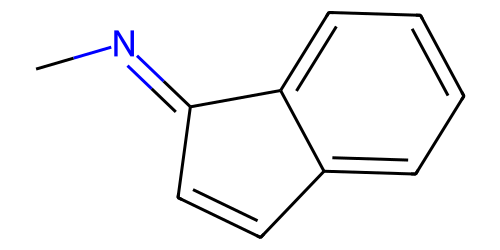

Aromatic: CC1=C(C2=CC=CC=C2C(=C1)C)SC
Kekule:   CSC1=C(C)C=C(C)C2=CC=CC=C21

Structure of CSC1=C(C)C=C(C)C2=CC=CC=C21


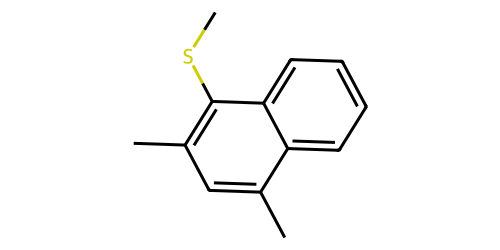

Aromatic: C1=C(C=[N+](C=C1S(=O)(=O)N)[S-])[S-]
Kekule:   NS(=O)(=O)C1=C[N+]([S-])=CC([S-])=C1

Structure of NS(=O)(=O)C1=C[N+]([S-])=CC([S-])=C1


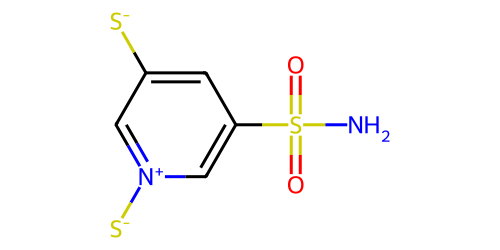

Aromatic: C1=CC=NC(=C1)S(=O)(=O)N
Kekule:   NS(=O)(=O)C1=CC=CC=N1

Structure of NS(=O)(=O)C1=CC=CC=N1


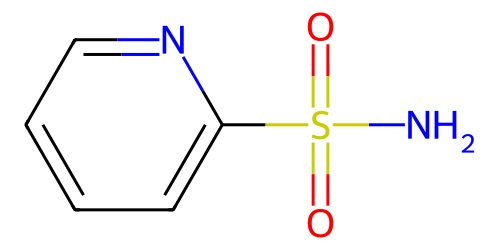

Aromatic: C1=CNC(=S)N=C1
Kekule:   S=C1N=CC=CN1

Structure of S=C1N=CC=CN1


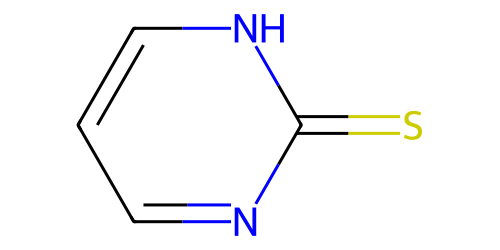

Aromatic: C[C@@H]1[C@H](C=C[C@@H](O1)N2C=CC(=NC2=O)C)SC
Kekule:   CS[C@H]1C=C[C@H](N2C=CC(C)=NC2=O)O[C@@H]1C

Structure of CS[C@H]1C=C[C@H](N2C=CC(C)=NC2=O)O[C@@H]1C


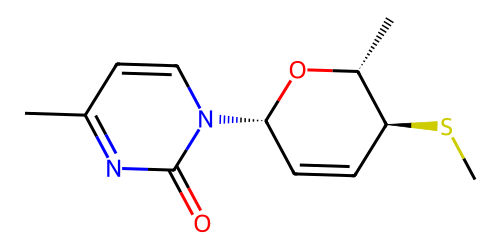

Aromatic: C[S+](C)C1=CN=CC=C1
Kekule:   C[S+](C)C1=CN=CC=C1

Structure of C[S+](C)C1=CN=CC=C1


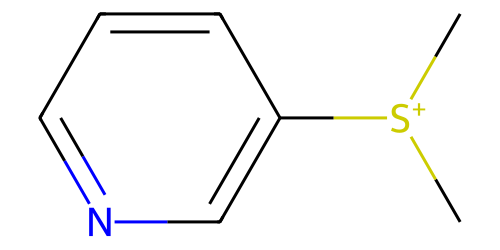

Aromatic: C[S+](C)C1=CC=CC=C1
Kekule:   C[S+](C)C1=CC=CC=C1

Structure of C[S+](C)C1=CC=CC=C1


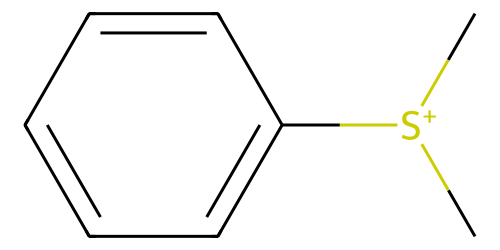

Aromatic: CNC1=CC=CC=C1
Kekule:   CNC1=CC=CC=C1

Structure of CNC1=CC=CC=C1


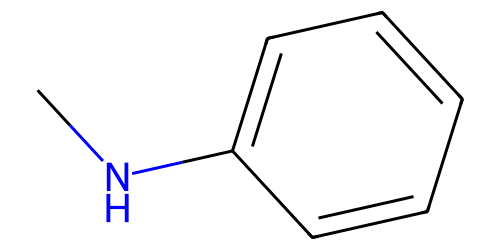

Aromatic: CN(C)C1=CC=C(C=C1)C2=CC=CC=N2
Kekule:   CN(C)C1=CC=C(C2=CC=CC=N2)C=C1

Structure of CN(C)C1=CC=C(C2=CC=CC=N2)C=C1


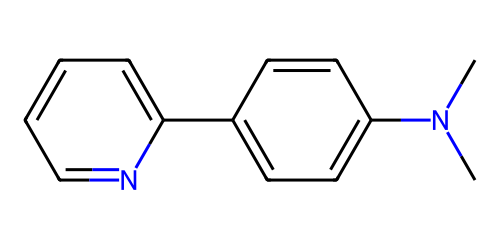

Aromatic: CNC1=CC=CC=C1
Kekule:   CNC1=CC=CC=C1

Structure of CNC1=CC=CC=C1


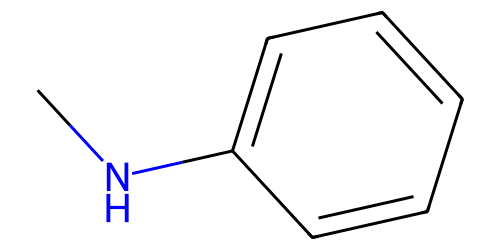

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


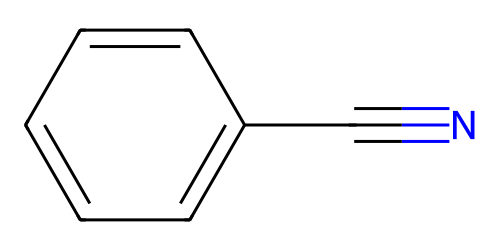

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


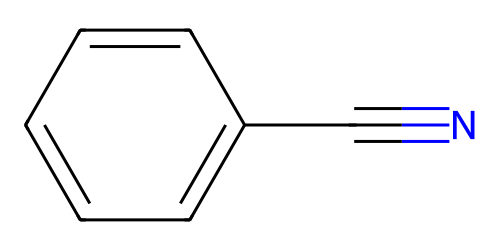

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


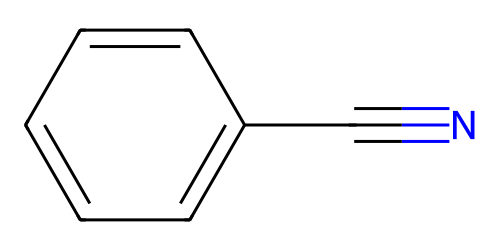

Aromatic: C1=CC=C2C(=C1)C=CC3=C2C4=CC=CC=C4C=C3
Kekule:   C1=CC=C2C(=C1)C=CC1=C2C2=CC=CC=C2C=C1

Structure of C1=CC=C2C(=C1)C=CC1=C2C2=CC=CC=C2C=C1


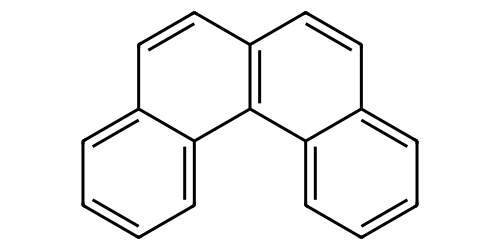

Aromatic: C1=CC=C2C(=C1)C=CC3=C2C4=CC=CC=C4C=C3
Kekule:   C1=CC=C2C(=C1)C=CC1=C2C2=CC=CC=C2C=C1

Structure of C1=CC=C2C(=C1)C=CC1=C2C2=CC=CC=C2C=C1


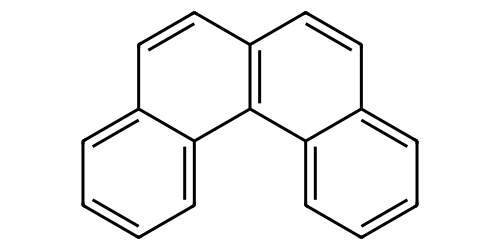

Aromatic: C1=CC=C2C(=C1)C=CC3=C2C4=CC=CC=C4C=C3
Kekule:   C1=CC=C2C(=C1)C=CC1=C2C2=CC=CC=C2C=C1

Structure of C1=CC=C2C(=C1)C=CC1=C2C2=CC=CC=C2C=C1


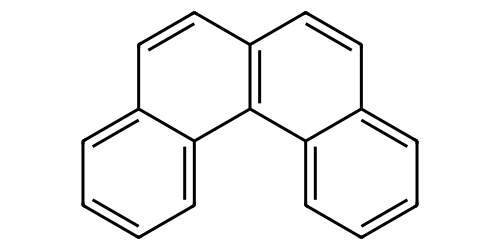

Aromatic: C1=CC=C2C(=C1)C3=CC=CC=C3S2
Kekule:   C1=CC=C2C(=C1)SC1=CC=CC=C12

Structure of C1=CC=C2C(=C1)SC1=CC=CC=C12


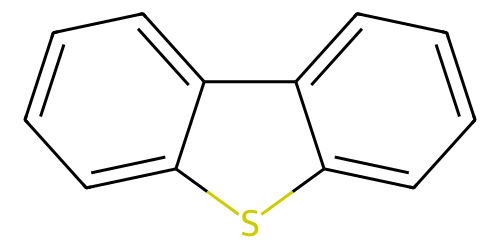

Aromatic: C1=CC=C2C(=C1)C3=CC=CC=C3S2
Kekule:   C1=CC=C2C(=C1)SC1=CC=CC=C12

Structure of C1=CC=C2C(=C1)SC1=CC=CC=C12


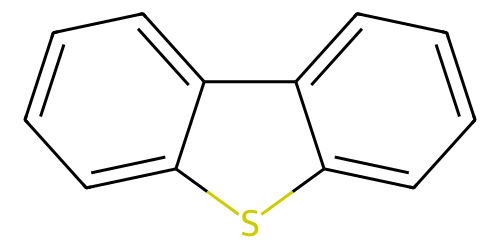

Aromatic: C1=CC=C2C(=C1)C3=CC=CC=C3S2
Kekule:   C1=CC=C2C(=C1)SC1=CC=CC=C12

Structure of C1=CC=C2C(=C1)SC1=CC=CC=C12


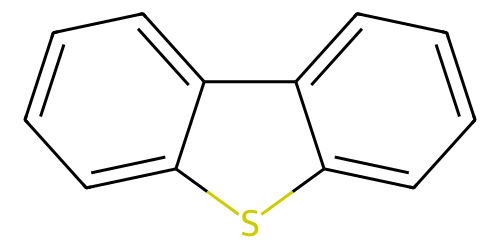

Aromatic: C1=CSC(=C1)C2=CSC(=C2)C3=CC=CS3
Kekule:   C1=CSC(C2=CSC(C3=CC=CS3)=C2)=C1

Structure of C1=CSC(C2=CSC(C3=CC=CS3)=C2)=C1


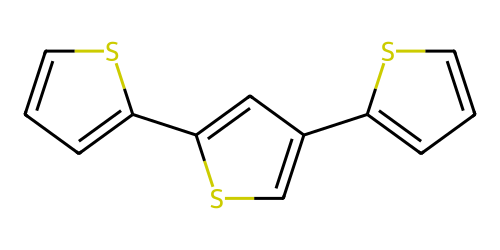

Aromatic: C1=CSC(=C1)C2=CSC(=C2)C3=CC=CS3
Kekule:   C1=CSC(C2=CSC(C3=CC=CS3)=C2)=C1

Structure of C1=CSC(C2=CSC(C3=CC=CS3)=C2)=C1


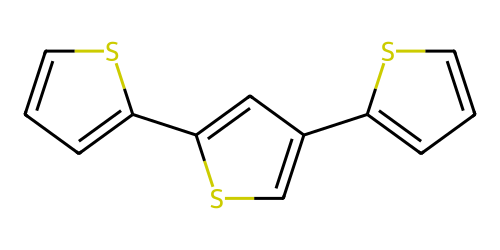

Aromatic: C1=CSC(=C1)C2=CSC(=C2)C3=CC=CS3
Kekule:   C1=CSC(C2=CSC(C3=CC=CS3)=C2)=C1

Structure of C1=CSC(C2=CSC(C3=CC=CS3)=C2)=C1


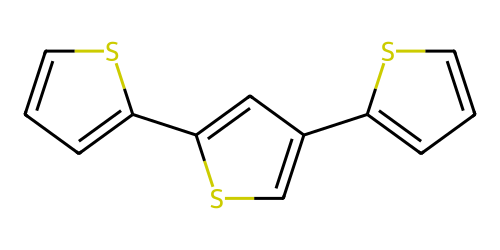

Aromatic: C1=CC(=C(C=C1C2=CC(=C(C=C2)N)N)N)N
Kekule:   NC1=C(N)C=C(C2=CC(N)=C(N)C=C2)C=C1

Structure of NC1=C(N)C=C(C2=CC(N)=C(N)C=C2)C=C1


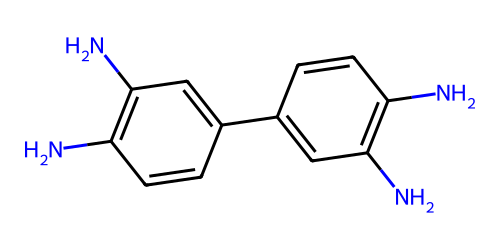

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=C(N)C=C2)C=C1

Structure of NC1=CC=C(C2=CC=C(N)C=C2)C=C1


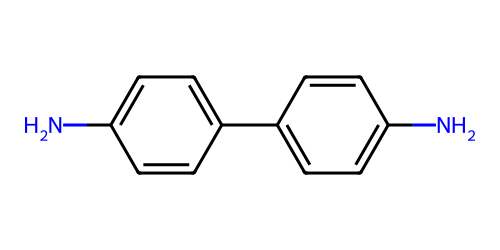

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=C(N)C=C2)C=C1

Structure of NC1=CC=C(C2=CC=C(N)C=C2)C=C1


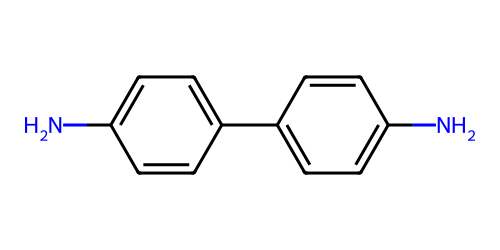

Aromatic: C1=CC2=C3C(=C1)C=CC4=CC=CC(=C43)C=C2
Kekule:   C1=CC2=C3C(=C1)C=CC1=CC=CC(=C13)C=C2

Structure of C1=CC2=C3C(=C1)C=CC1=CC=CC(=C13)C=C2


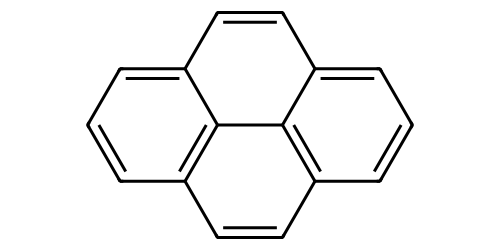

Aromatic: C1=CC=C(C=C1)C2=CC=C(O2)CN3C=CC=C3
Kekule:   C1=CC=C(C2=CC=C(CN3C=CC=C3)O2)C=C1

Structure of C1=CC=C(C2=CC=C(CN3C=CC=C3)O2)C=C1


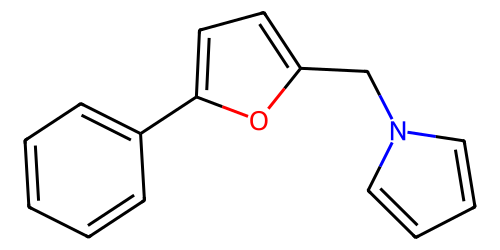

Aromatic: C1=CC2=C3C(=C1)C=CC4=CC=CC(=C43)C=C2
Kekule:   C1=CC2=C3C(=C1)C=CC1=CC=CC(=C13)C=C2

Structure of C1=CC2=C3C(=C1)C=CC1=CC=CC(=C13)C=C2


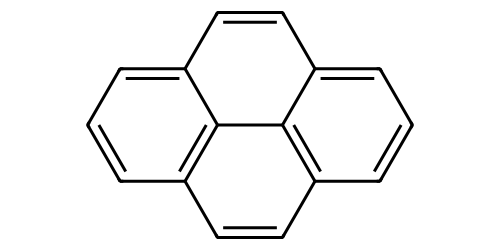

Aromatic: C[S+](C)C1=CC=CC2=CC=CC=C21
Kekule:   C[S+](C)C1=CC=CC2=CC=CC=C21

Structure of C[S+](C)C1=CC=CC2=CC=CC=C21


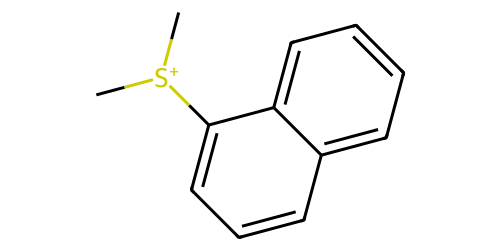

Aromatic: CC(=O)OC1=CC2=CC=CC=C2C=C1
Kekule:   CC(=O)OC1=CC2=CC=CC=C2C=C1

Structure of CC(=O)OC1=CC2=CC=CC=C2C=C1


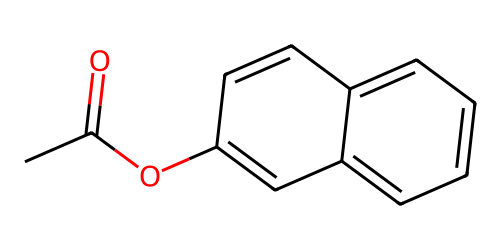

Aromatic: C[Si](C)(C)C1=CC=CC2=CC=CC=C21
Kekule:   C[Si](C)(C)C1=CC=CC2=CC=CC=C21

Structure of C[Si](C)(C)C1=CC=CC2=CC=CC=C21


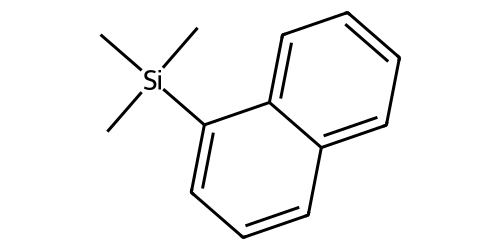

Aromatic: CS(=O)(=O)C1=CC=CC2=C1C3=CC=CC=C3C2
Kekule:   CS(=O)(=O)C1=CC=CC2=C1C1=CC=CC=C1C2

Structure of CS(=O)(=O)C1=CC=CC2=C1C1=CC=CC=C1C2


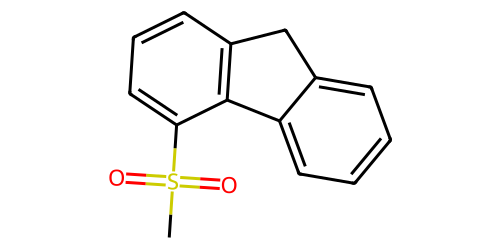

Aromatic: CS(=O)(=O)C1=CC=CC2=C1C3=CC=CC=C3C2
Kekule:   CS(=O)(=O)C1=CC=CC2=C1C1=CC=CC=C1C2

Structure of CS(=O)(=O)C1=CC=CC2=C1C1=CC=CC=C1C2


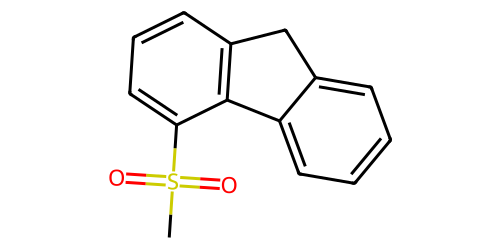

Aromatic: CSC1=CC=CC=C1C2=CC=CC=C2
Kekule:   CSC1=CC=CC=C1C1=CC=CC=C1

Structure of CSC1=CC=CC=C1C1=CC=CC=C1


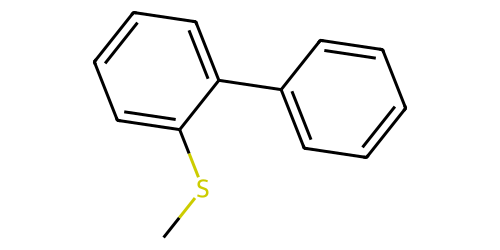

Aromatic: C1=CSC(=C1)C(=O)O
Kekule:   O=C(O)C1=CC=CS1

Structure of O=C(O)C1=CC=CS1


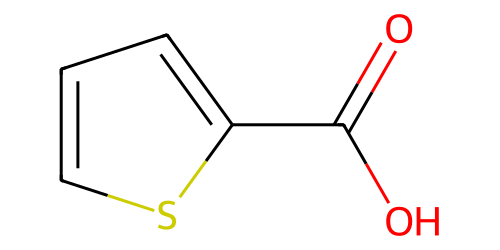

Aromatic: C1=CSC(=C1)C(=O)C2=CC=C(S2)C(=O)O
Kekule:   O=C(O)C1=CC=C(C(=O)C2=CC=CS2)S1

Structure of O=C(O)C1=CC=C(C(=O)C2=CC=CS2)S1


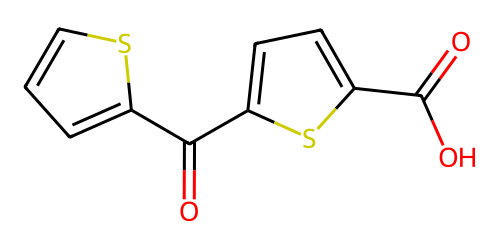

Aromatic: C1=CSC(=C1)C(=O)O
Kekule:   O=C(O)C1=CC=CS1

Structure of O=C(O)C1=CC=CS1


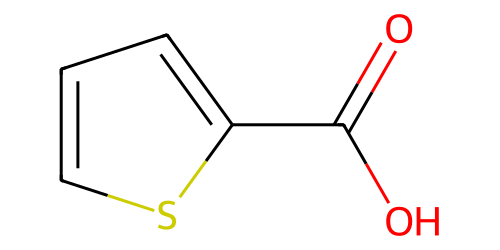

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C32
Kekule:   C1=CC=C2C(=C1)C=CC1=CC=CC=C12

Structure of C1=CC=C2C(=C1)C=CC1=CC=CC=C12


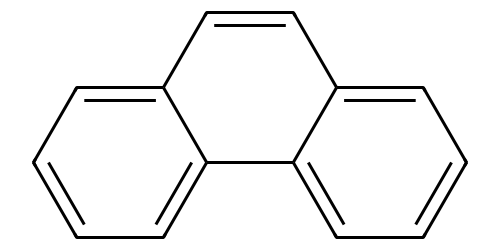

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C3N2
Kekule:   C1=CC=C2NC3=CC=CC=C3C=CC2=C1

Structure of C1=CC=C2NC3=CC=CC=C3C=CC2=C1


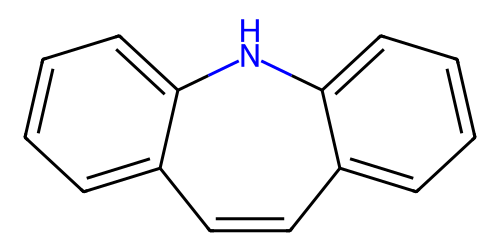

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C32
Kekule:   C1=CC=C2C(=C1)C=CC1=CC=CC=C12

Structure of C1=CC=C2C(=C1)C=CC1=CC=CC=C12


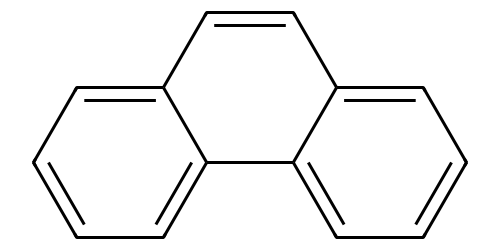

Aromatic: CC1=C(C2=CC=CC=C2C(=C1)N)N
Kekule:   CC1=C(N)C2=CC=CC=C2C(N)=C1

Structure of CC1=C(N)C2=CC=CC=C2C(N)=C1


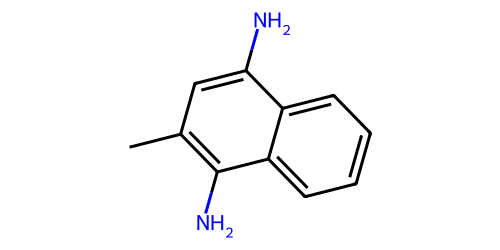

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C3N2
Kekule:   C1=CC=C2NC3=CC=CC=C3C=CC2=C1

Structure of C1=CC=C2NC3=CC=CC=C3C=CC2=C1


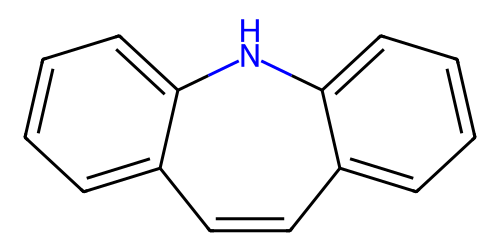

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C3N2
Kekule:   C1=CC=C2NC3=CC=CC=C3C=CC2=C1

Structure of C1=CC=C2NC3=CC=CC=C3C=CC2=C1


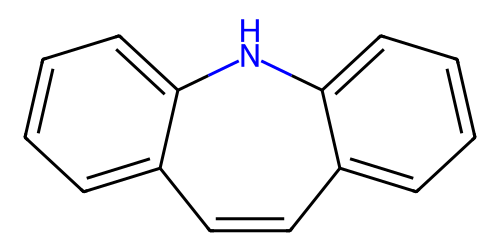

Aromatic: C1=CC=NC(=C1)C2=CC=CC=N2
Kekule:   C1=CC=C(C2=CC=CC=N2)N=C1

Structure of C1=CC=C(C2=CC=CC=N2)N=C1


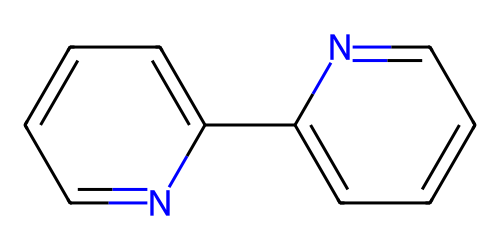

Aromatic: C1=CC=NC(=C1)C2=CC=CC=N2
Kekule:   C1=CC=C(C2=CC=CC=N2)N=C1

Structure of C1=CC=C(C2=CC=CC=N2)N=C1


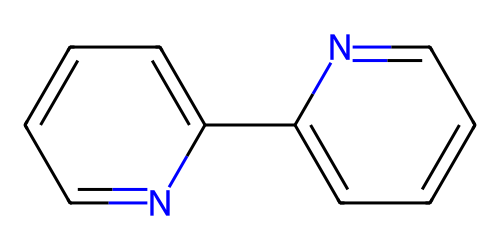

Aromatic: C1=CC2=NC3=CC=CC=C3C=C2
Kekule:   None



[16:19:39] SMILES Parse Error: unclosed ring for input: 'C1=CC2=NC3=CC=CC=C3C=C2'


In [13]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = mt5_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中


Aromatic: C1=CC(=CN=C1)C2=CC=NC=C2
Kekule:   C1=CC(C2=CC=NC=C2)=CN=C1

Structure of C1=CC(C2=CC=NC=C2)=CN=C1


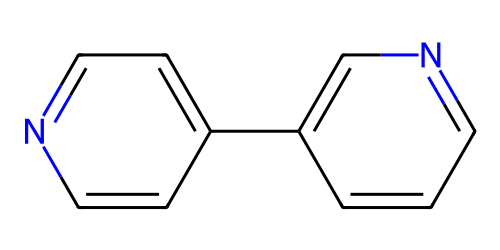

Aromatic: CC(=O)N1CCCC1
Kekule:   CC(=O)N1CCCC1

Structure of CC(=O)N1CCCC1


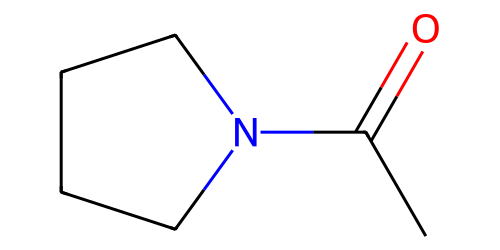

Aromatic: CC(=O)C1=CC=CN1
Kekule:   CC(=O)C1=CC=CN1

Structure of CC(=O)C1=CC=CN1


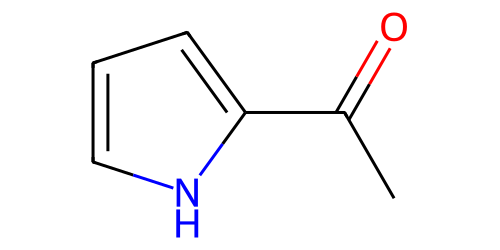

Aromatic: C1=CC=C(C=C1)C(C2=CC=CC=C2)(C3=CC=CC=C3)C(=O)O
Kekule:   O=C(O)C(C1=CC=CC=C1)(C1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C(O)C(C1=CC=CC=C1)(C1=CC=CC=C1)C1=CC=CC=C1


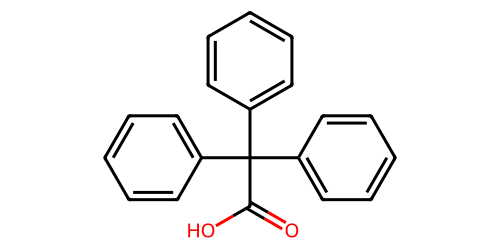

Aromatic: C1=CC=C(C=C1)C(C2=CC=CC=C2)C(=O)[O-]
Kekule:   O=C([O-])C(C1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C([O-])C(C1=CC=CC=C1)C1=CC=CC=C1


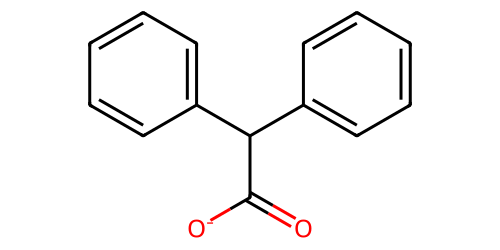

Aromatic: CCC1=CC=CC=C1CC2=CC=CC=C2
Kekule:   CCC1=CC=CC=C1CC1=CC=CC=C1

Structure of CCC1=CC=CC=C1CC1=CC=CC=C1


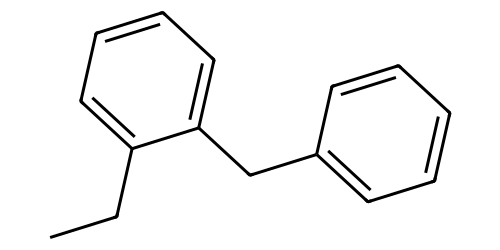

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C3S2
Kekule:   C1=CC=C2SC3=CC=CC=C3C=CC2=C1

Structure of C1=CC=C2SC3=CC=CC=C3C=CC2=C1


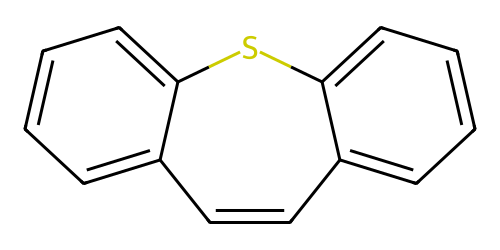

Aromatic: CC1=CC2=C(C=C1S(=O)(=O)[O-])C(=C3C=C(C(=[NH+]CC)C=C3O2)C)C4=C(C=C(C=C4)S(=O)(=O)[O-])S(=O)(=O)[O-]
Kekule:   CC[NH+]=C1C=C2OC3=C(C=C(S(=O)(=O)[O-])C(C)=C3)C(C3=C(S(=O)(=O)[O-])C=C(S(=O)(=O)[O-])C=C3)=C2C=C1C

Structure of CC[NH+]=C1C=C2OC3=C(C=C(S(=O)(=O)[O-])C(C)=C3)C(C3=C(S(=O)(=O)[O-])C=C(S(=O)(=O)[O-])C=C3)=C2C=C1C


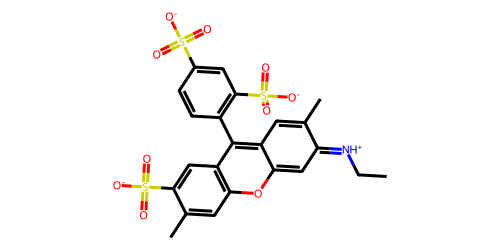

Aromatic: CC1=C(C2=CC3=C(C(=C(C=C3)S(=O)(=O)O)S(=O)(=O)O)C(=C2C1=O)O)C
Kekule:   CC1=C(C)C2=CC3=C(C(O)=C2C1=O)C(S(=O)(=O)O)=C(S(=O)(=O)O)C=C3

Structure of CC1=C(C)C2=CC3=C(C(O)=C2C1=O)C(S(=O)(=O)O)=C(S(=O)(=O)O)C=C3


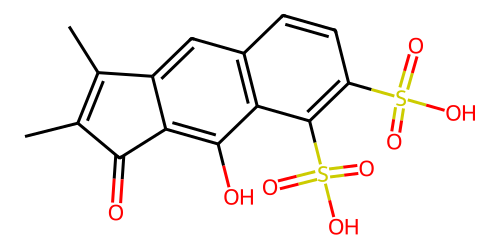

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2N
Kekule:   NC1=CC=CC=C1C1=CC=CC=C1

Structure of NC1=CC=CC=C1C1=CC=CC=C1


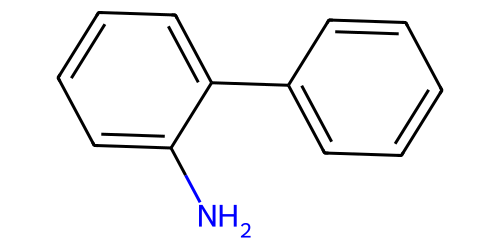

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2N
Kekule:   NC1=CC=CC=C1C1=CC=CC=C1

Structure of NC1=CC=CC=C1C1=CC=CC=C1


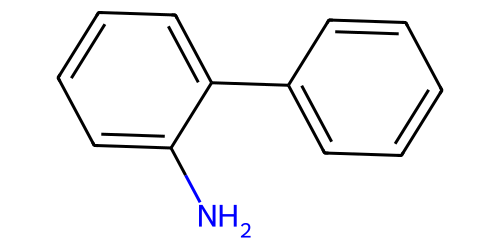

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2N
Kekule:   NC1=CC=CC=C1C1=CC=CC=C1

Structure of NC1=CC=CC=C1C1=CC=CC=C1


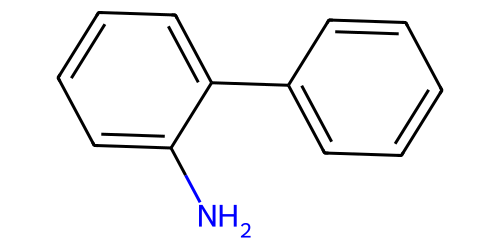

Aromatic: CSC1=CC=CC2=CC=CC=C21
Kekule:   CSC1=CC=CC2=CC=CC=C21

Structure of CSC1=CC=CC2=CC=CC=C21


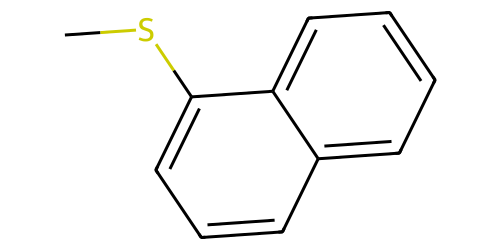

Aromatic: CSC1=CC=CC2=CC=CC=C21
Kekule:   CSC1=CC=CC2=CC=CC=C21

Structure of CSC1=CC=CC2=CC=CC=C21


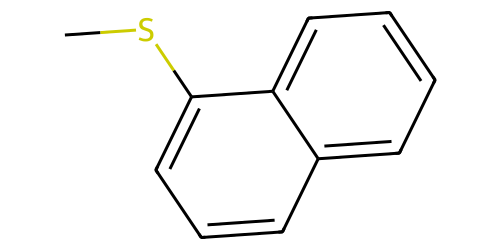

Aromatic: CSC1=CC=CC2=CC=CC=C21
Kekule:   CSC1=CC=CC2=CC=CC=C21

Structure of CSC1=CC=CC2=CC=CC=C21


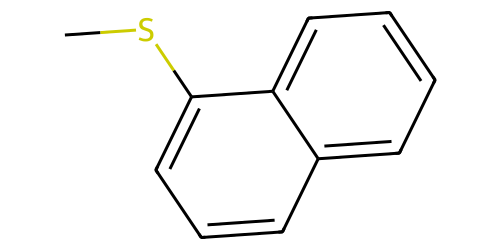

Aromatic: C1=CC(=NC(=C1)S(=O)(=O)O)S(=O)(=O)O
Kekule:   O=S(=O)(O)C1=CC=CC(S(=O)(=O)O)=N1

Structure of O=S(=O)(O)C1=CC=CC(S(=O)(=O)O)=N1


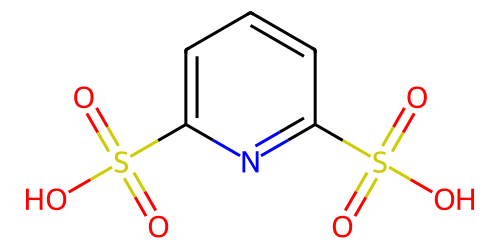

Aromatic: C1=CC=NC(=C1)S(=O)(=O)[O-]
Kekule:   O=S(=O)([O-])C1=CC=CC=N1

Structure of O=S(=O)([O-])C1=CC=CC=N1


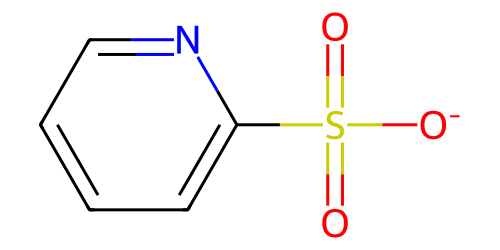

Aromatic: C1=CC=NC(=C1)SCC2=CC=CC=N2
Kekule:   C1=CC=C(CSC2=CC=CC=N2)N=C1

Structure of C1=CC=C(CSC2=CC=CC=N2)N=C1


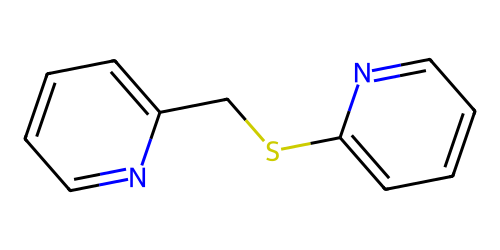

Aromatic: CSCC[C@H]1C(=O)NC(=C)C1
Kekule:   C=C1C[C@@H](CCSC)C(=O)N1

Structure of C=C1C[C@@H](CCSC)C(=O)N1


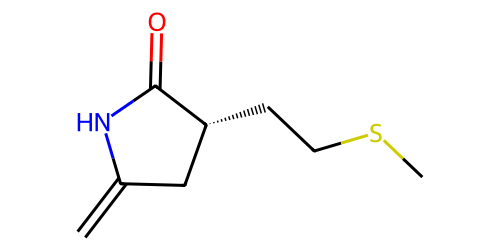

Aromatic: CC(=O)SCC1=CN=C(N=C1)C2=CC=CC=N2
Kekule:   CC(=O)SCC1=CN=C(C2=CC=CC=N2)N=C1

Structure of CC(=O)SCC1=CN=C(C2=CC=CC=N2)N=C1


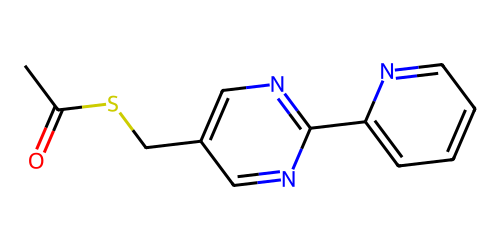

Aromatic: CSCC[C@@H]1[C@H](C(=O)N=C(S1)N)NC(=O)[C@@H](C(=O)O)N
Kekule:   CSCC[C@H]1SC(N)=NC(=O)[C@@H]1NC(=O)[C@H](N)C(=O)O

Structure of CSCC[C@H]1SC(N)=NC(=O)[C@@H]1NC(=O)[C@H](N)C(=O)O


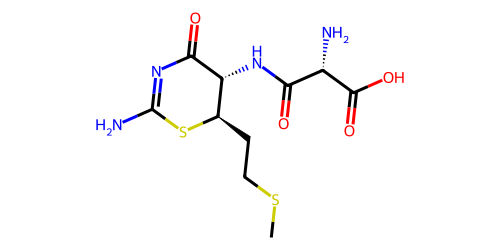

Aromatic: C[N+]1=CC=CC=C1/C=C/C2=CC=CC=C2
Kekule:   C[N+]1=CC=CC=C1/C=C/C1=CC=CC=C1

Structure of C[N+]1=CC=CC=C1/C=C/C1=CC=CC=C1


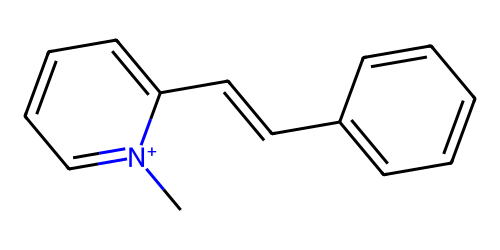

Aromatic: CN(C)C1=CC=C(C=C1)C2=CC=CC=C2
Kekule:   CN(C)C1=CC=C(C2=CC=CC=C2)C=C1

Structure of CN(C)C1=CC=C(C2=CC=CC=C2)C=C1


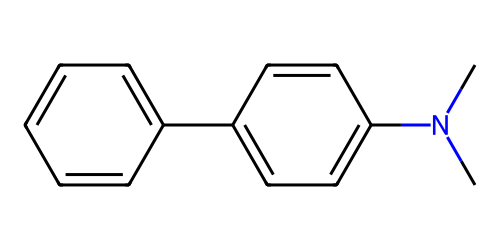

Aromatic: C[N+]1=CC=CC=C1/C=C/C2=CC=CC=C2
Kekule:   C[N+]1=CC=CC=C1/C=C/C1=CC=CC=C1

Structure of C[N+]1=CC=CC=C1/C=C/C1=CC=CC=C1


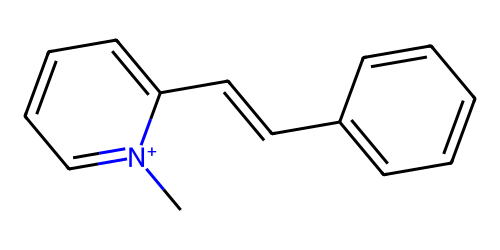

Aromatic: C1=CC=C(C=C1)C(=O)C2=CC=C(C=C2)N=C=O
Kekule:   O=C=NC1=CC=C(C(=O)C2=CC=CC=C2)C=C1

Structure of O=C=NC1=CC=C(C(=O)C2=CC=CC=C2)C=C1


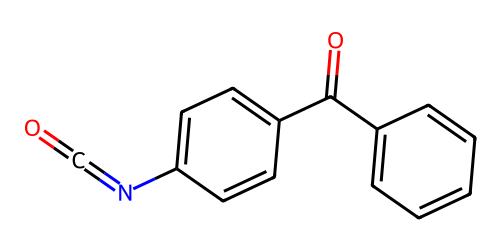

Aromatic: C1=CC=C2C(=C1)C=CC(=C2N=C=O)C#N
Kekule:   N#CC1=C(N=C=O)C2=CC=CC=C2C=C1

Structure of N#CC1=C(N=C=O)C2=CC=CC=C2C=C1


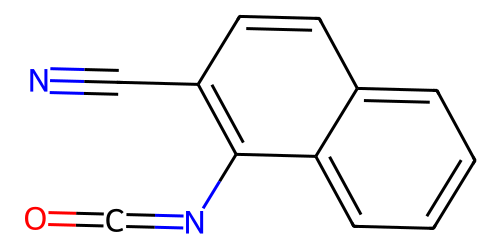

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


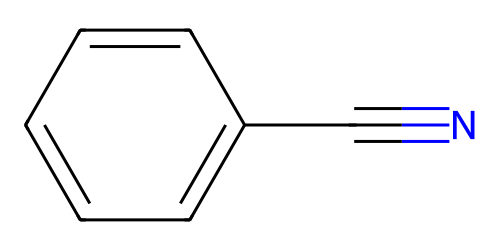

Aromatic: C1=CC=C2C(=C1)C=C(C(=C2I)N=I)I
Kekule:   IC1=CC2=CC=CC=C2C(I)=C1N=[IH]

Structure of IC1=CC2=CC=CC=C2C(I)=C1N=[IH]


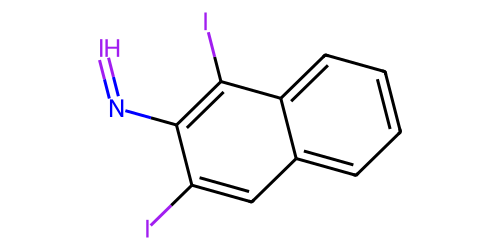

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2I
Kekule:   IC1=CC=CC=C1C1=CC=CC=C1

Structure of IC1=CC=CC=C1C1=CC=CC=C1


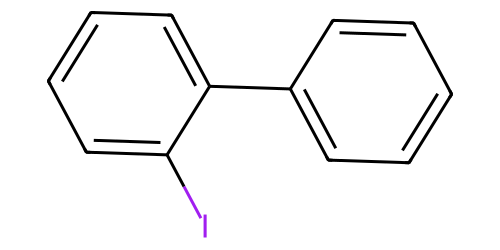

Aromatic: C1=CC=C2C(=C1)C=CC(=C2I)I
Kekule:   IC1=C(I)C2=CC=CC=C2C=C1

Structure of IC1=C(I)C2=CC=CC=C2C=C1


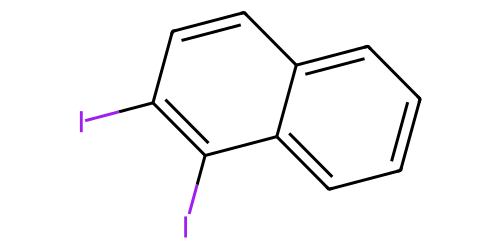

Aromatic: C1=CSC(=C1)C2=CC=C(C=C2)C3=CC=C(S3)C4=CC=CS4
Kekule:   C1=CSC(C2=CC=C(C3=CC=C(C4=CC=CS4)S3)C=C2)=C1

Structure of C1=CSC(C2=CC=C(C3=CC=C(C4=CC=CS4)S3)C=C2)=C1


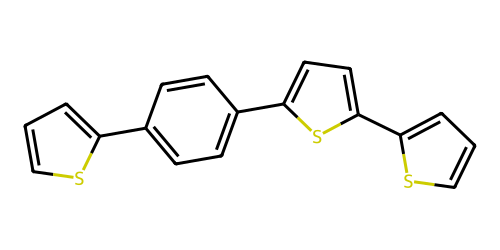

Aromatic: C1=CC=C(C=C1)C2=C(SC(=C2)C3=CC=CS3)C4=CC=CC=C4
Kekule:   C1=CC=C(C2=C(C3=CC=CC=C3)SC(C3=CC=CS3)=C2)C=C1

Structure of C1=CC=C(C2=C(C3=CC=CC=C3)SC(C3=CC=CS3)=C2)C=C1


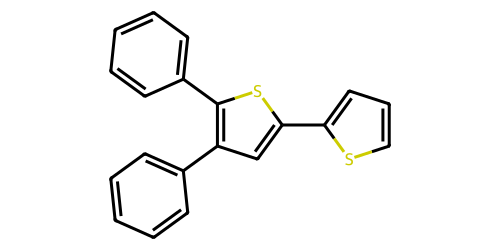

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C3S2
Kekule:   C1=CC=C2SC3=CC=CC=C3C=CC2=C1

Structure of C1=CC=C2SC3=CC=CC=C3C=CC2=C1


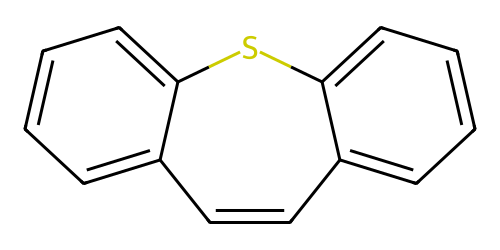

Aromatic: C1=CSC(=C1)C2=CC=CS2
Kekule:   C1=CSC(C2=CC=CS2)=C1

Structure of C1=CSC(C2=CC=CS2)=C1


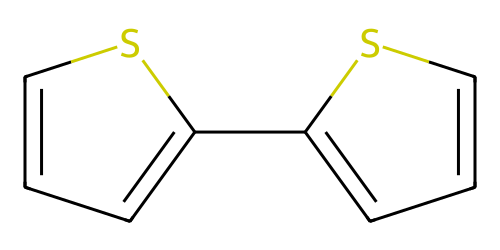

Aromatic: C1=CSC(=C1)C2=CC=CS2
Kekule:   C1=CSC(C2=CC=CS2)=C1

Structure of C1=CSC(C2=CC=CS2)=C1


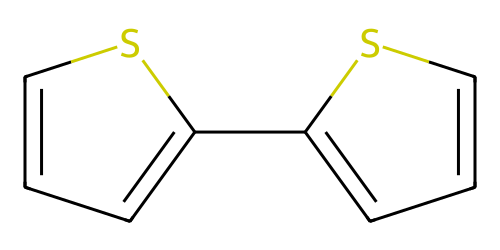

Aromatic: C1=CSC(=C1)C2=CC=CS2
Kekule:   C1=CSC(C2=CC=CS2)=C1

Structure of C1=CSC(C2=CC=CS2)=C1


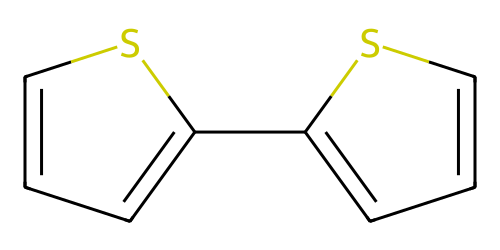

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)N
Kekule:   NC1=CC=C(C2=CC=CC=C2)C=C1

Structure of NC1=CC=C(C2=CC=CC=C2)C=C1


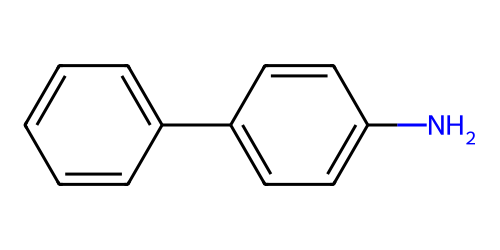

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)N
Kekule:   NC1=CC=C(C2=CC=CC=C2)C=C1

Structure of NC1=CC=C(C2=CC=CC=C2)C=C1


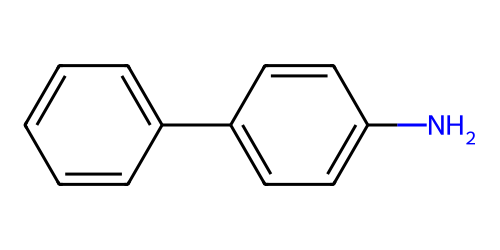

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)N
Kekule:   NC1=CC=C(C2=CC=CC=C2)C=C1

Structure of NC1=CC=C(C2=CC=CC=C2)C=C1


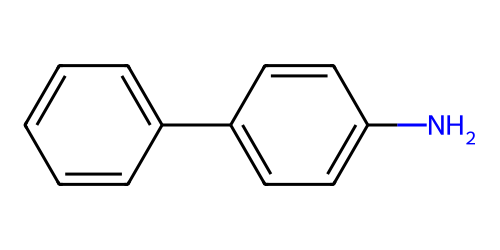

Aromatic: CC1=CC=C(O1)C2=CC=CC=N2
Kekule:   CC1=CC=C(C2=CC=CC=N2)O1

Structure of CC1=CC=C(C2=CC=CC=N2)O1


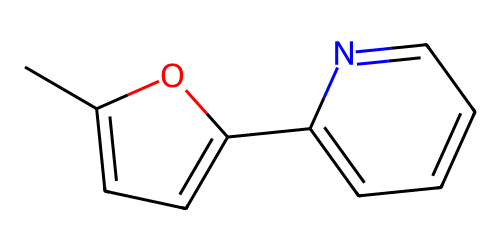

Aromatic: CC1=CC=C(O1)C2=CC=CC=N2
Kekule:   CC1=CC=C(C2=CC=CC=N2)O1

Structure of CC1=CC=C(C2=CC=CC=N2)O1


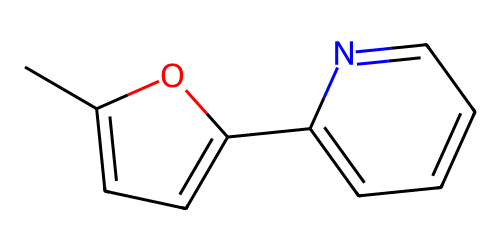

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C32
Kekule:   C1=CC=C2C(=C1)C=CC1=CC=CC=C12

Structure of C1=CC=C2C(=C1)C=CC1=CC=CC=C12


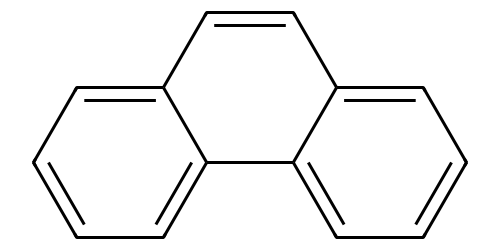

Aromatic: CSC1=CC=CC2=CC=CC=C21
Kekule:   CSC1=CC=CC2=CC=CC=C21

Structure of CSC1=CC=CC2=CC=CC=C21


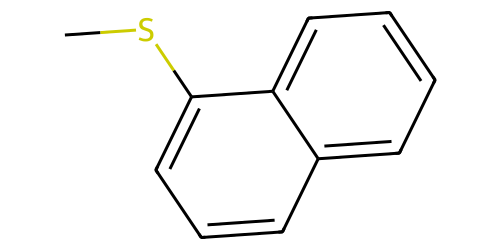

Aromatic: CC1=CC=CC2=CC=CC=C12
Kekule:   CC1=CC=CC2=CC=CC=C12

Structure of CC1=CC=CC2=CC=CC=C12


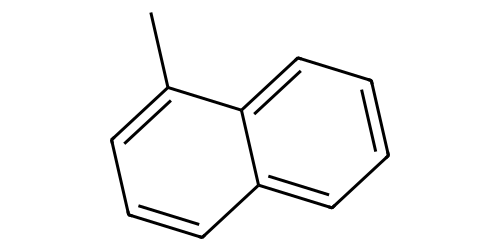

Aromatic: CSC1=CC=CC2=CC=CC=C21
Kekule:   CSC1=CC=CC2=CC=CC=C21

Structure of CSC1=CC=CC2=CC=CC=C21


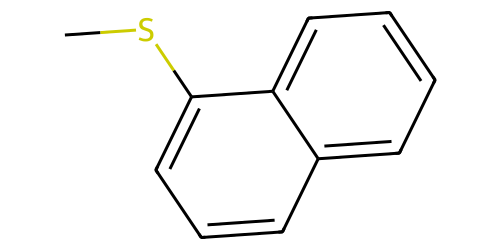

Aromatic: CC1=CC(=C(C=C1)S(=O)(=O)[O-])C(F)(F)F
Kekule:   CC1=CC(C(F)(F)F)=C(S(=O)(=O)[O-])C=C1

Structure of CC1=CC(C(F)(F)F)=C(S(=O)(=O)[O-])C=C1


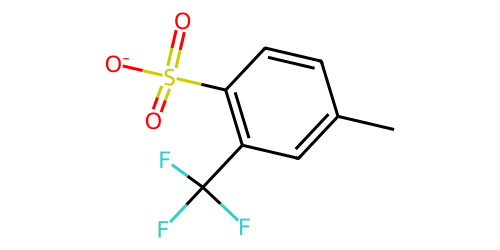

Aromatic: CS(=O)(=O)CC1=CC2=C(C=C1)C3=CC=CC=C3S2
Kekule:   CS(=O)(=O)CC1=CC2=C(C=C1)C1=CC=CC=C1S2

Structure of CS(=O)(=O)CC1=CC2=C(C=C1)C1=CC=CC=C1S2


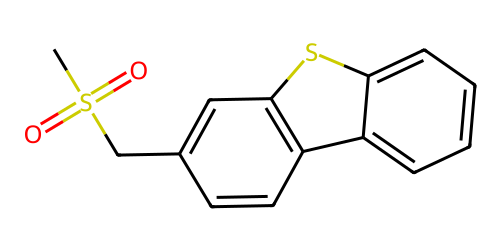

Aromatic: CSC1=CC=CC2=C1C3=CC=CC=C3S2
Kekule:   CSC1=CC=CC2=C1C1=CC=CC=C1S2

Structure of CSC1=CC=CC2=C1C1=CC=CC=C1S2


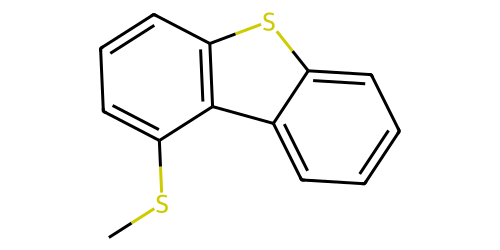

Aromatic: C1=CSC(=C1)C(=O)[O-]
Kekule:   O=C([O-])C1=CC=CS1

Structure of O=C([O-])C1=CC=CS1


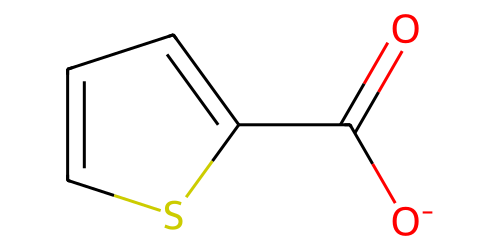

Aromatic: C1=CSC(=C1)C(=O)O
Kekule:   O=C(O)C1=CC=CS1

Structure of O=C(O)C1=CC=CS1


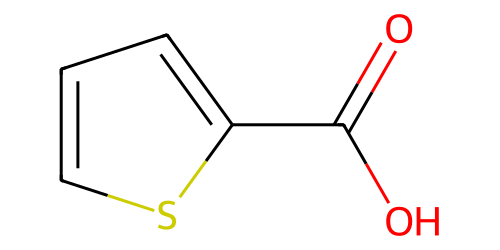

Aromatic: C1=CSC(=C1)C(=O)S
Kekule:   O=C(S)C1=CC=CS1

Structure of O=C(S)C1=CC=CS1


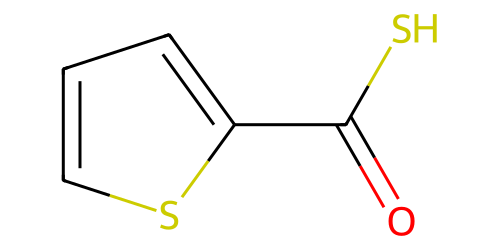

Aromatic: C1=CC=C(C=C1)C2=CC=C(O2)CN
Kekule:   NCC1=CC=C(C2=CC=CC=C2)O1

Structure of NCC1=CC=C(C2=CC=CC=C2)O1


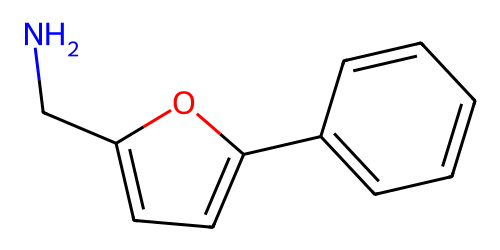

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C3N2
Kekule:   C1=CC=C2NC3=CC=CC=C3C=CC2=C1

Structure of C1=CC=C2NC3=CC=CC=C3C=CC2=C1


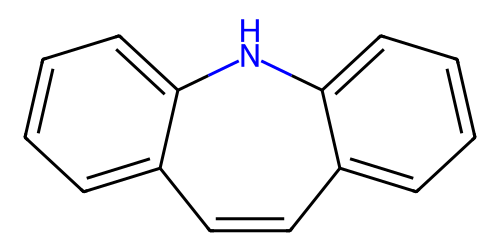

Aromatic: C1=CC(=CC=C1N)2=CC=C(O2)CN
Kekule:   None

Aromatic: C1=CC=C(C(=C1)N)N
Kekule:   NC1=CC=CC=C1N

Structure of NC1=CC=CC=C1N


[16:19:43] Explicit valence for atom # 2 C, 6, is greater than permitted


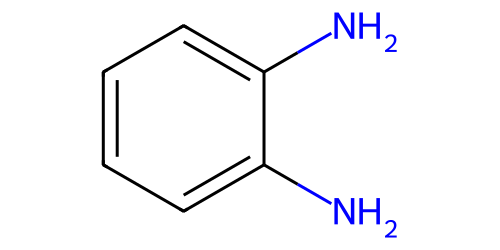

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C3N2
Kekule:   C1=CC=C2NC3=CC=CC=C3C=CC2=C1

Structure of C1=CC=C2NC3=CC=CC=C3C=CC2=C1


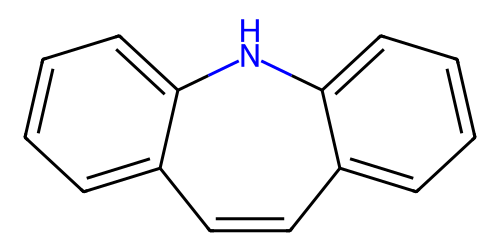

Aromatic: C1=CC=C(C(=C1)N)N
Kekule:   NC1=CC=CC=C1N

Structure of NC1=CC=CC=C1N


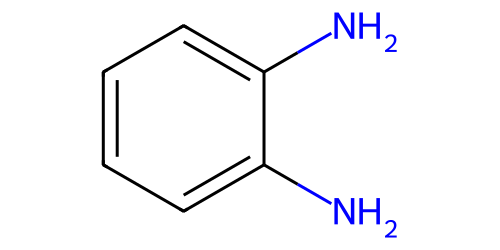

Aromatic: C1=CC=NC(=C1)C2=CC=CC=N2
Kekule:   C1=CC=C(C2=CC=CC=N2)N=C1

Structure of C1=CC=C(C2=CC=CC=N2)N=C1


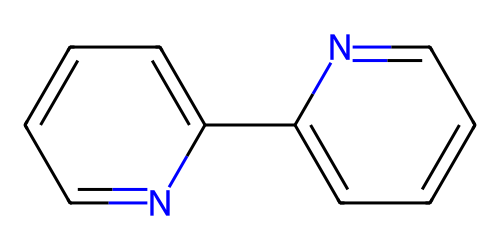

Aromatic: C1=CC=NC(=C1)C2=CC=CC=N2
Kekule:   C1=CC=C(C2=CC=CC=N2)N=C1

Structure of C1=CC=C(C2=CC=CC=N2)N=C1


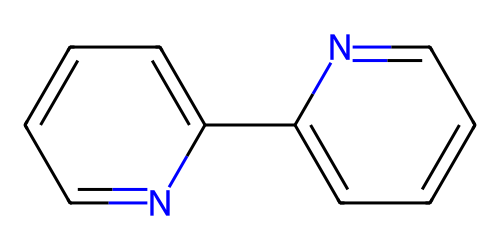

Aromatic: C1=CC=NC(=C1)C2=CC=CC=N2
Kekule:   C1=CC=C(C2=CC=CC=N2)N=C1

Structure of C1=CC=C(C2=CC=CC=N2)N=C1


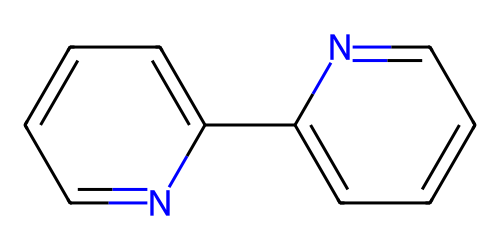

In [14]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = t5_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中
